# Demo 01: Clean MOF synthesis extraction records

This notebook demonstrates the data-cleaning workflow used to convert raw MOF synthesis extraction records into a normalized table for downstream model preparation.

**Input files expected in the same folder**

- `mof_extraction.csv`
- `linker and mw.csv`

**Main output**

- `mof_extraction_1_2_3_4_5_6.csv`

Run this notebook from top to bottom before running `demo_02_prepare_json_for_fine_tuning.ipynb`.


## 1. Initial table cleanup and basic normalization

This step reads `mof_extraction.csv`, removes poorly populated or unusable entries, standardizes common text fields, and writes the first cleaned table.



Loaded mof_extraction.csv
Total rows: 23383

PDF availability counts
Have value in main_pdf: 21825
Have value in si_pdf: 19086
Have both: 18056
Only main not si: 3769
Only si not main: 1030
Neither: 528
After dropping rows with neither main_pdf nor si_pdf, rows left: 22855

article_trial_or_failure filter
Rows total before filter: 22855
Dropping rows where 'article_trial_or_failure' is neither yes nor no: 1052
Rows left: 21803

Drop rows with required empties
Dropping rows where any of ['metal_1', 'linker_1', 'solvent_main', 'solvent_main_abbr'] is empty: 744
Rows left: 21059

crystal_code cleaned
crystal_code changed: 16109
linker_1 trailing parens removed: 2204
linker_2 trailing parens removed: 15661
linker_3 trailing parens removed: 20960

Linker deep clean: synonym merge
linker_1: synonym merge changes: 3211
linker_2: synonym merge changes: 806
linker_3: synonym merge changes: 3

temperature_c cleaning
Rows to drop due to temperature_c_text containing microwave or evaporation or s

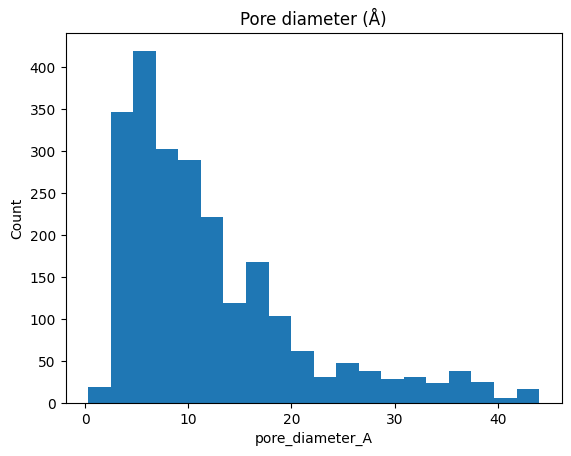


BET surface area (m²/g) distribution
BET_surface_area_m2g: numeric non empty count = 6064


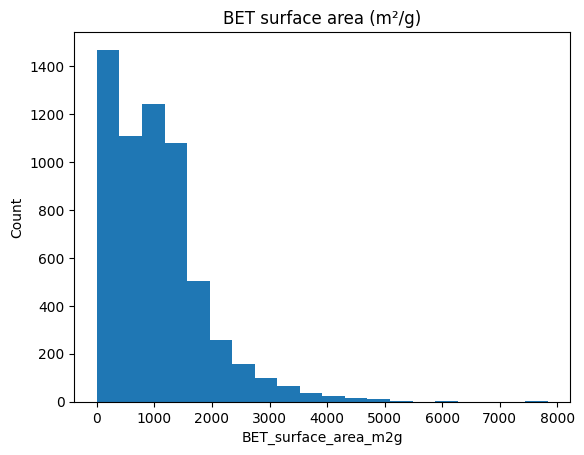


TGA decomposition temp (°C) distribution
tga_decomposition_temp_c: numeric non empty count = 6824


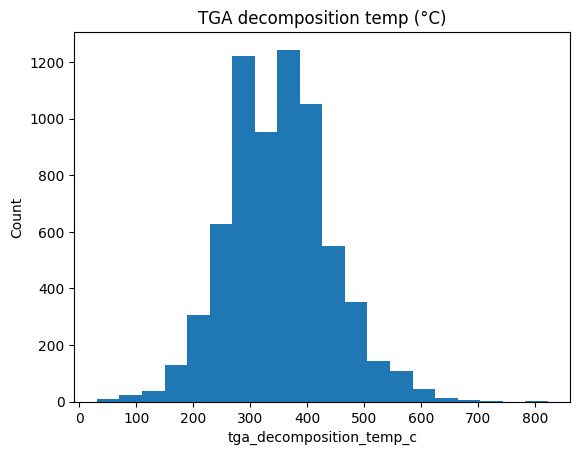


Topology report
Non-empty topology_code rows: 4864
Unique topology codes (case-insensitive): 300
Top 10 topology codes:
topology_code
fcu    588
pcu    473
sod    364
sql    334
dia    314
csq    110
hcb    104
mtn    102
rtl    100
flu     99

air_stable counts
yes: 1686
no: 171
not_reported: 14599
empty: 0
Top 10 values:
air_stable
not_reported    14599
nan              3341
yes              1686
no                171

water_stable counts
yes: 1819
no: 468
not_reported: 14255
empty: 0
Top 10 values:
water_stable
not_reported    14255
nan              3255
yes              1819
no                468

Wrote cleaned CSV to mof_extraction_1.csv


In [2]:
# Single-cell notebook to clean `mof_extraction.csv` and write `mof_extraction_1.csv`
# Prints required stats and plots simple distributions.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from pathlib import Path

# ---------- helpers ----------
def is_filled(x):
    if x is None:
        return False
    if isinstance(x, float) and np.isnan(x):
        return False
    s = str(x).strip()
    return s != "" and s.lower() not in {"nan", "none"}

def filled_series(s):
    return s.apply(is_filled)

def count_changes(before, after):
    return int((before.astype(str) != after.astype(str)).sum())

def print_header(msg):
    print("\n" + "=" * 80)
    print(msg)
    print("=" * 80)

def safe_lower(x):
    try:
        return str(x).strip().lower()
    except Exception:
        return ""

def strip_trailing_parens(val, keep_when="(anhydrous)"):
    """Remove a trailing ' ( ... )' only if it is not the allowed exception.
       If the trailing parens looks like a formula, keep only the inside.
       Returns new_val, changed_flag
    """
    if not is_filled(val):
        return val, False
    s = str(val).strip()
    m = re.search(r"\s\(([^)]*)\)\s*$", s)
    if not m:
        return s, False
    inside = m.group(1).strip()
    if keep_when and s.endswith(f" {keep_when}"):
        return s, False
    # If inside looks like a formula, prefer the inside (e.g., '... (Ti(iPrO)4)' -> 'Ti(iPrO)4')
    if re.fullmatch(r"[A-Za-z0-9·\[\]\(\)]+", inside):
        return inside, True
    # Otherwise remove the whole trailing parenthetical
    new_s = re.sub(r"\s\([^)]*\)\s*$", "", s)
    return new_s, new_s != s

def remove_linker_trailing_parens(val):
    """For linker names like 'salicylic acid (H2L1)' remove trailing ' (H2L1)'"""
    if not is_filled(val):
        return val, False
    s = str(val).strip()
    new_s = re.sub(r"\s\([^)]*\)\s*$", "", s)
    return new_s, new_s != s

def normalize_x_to_middle_dot(s):
    if not is_filled(s):
        return s, False
    new_s = str(s).replace(" × ", "·")
    return new_s, new_s != s

def extract_digits_after_ccdc(val):
    """For crystal_code: if contains 'CCDC', keep the digits; else if mixed, keep digits only."""
    if not is_filled(val):
        return val, False
    s = str(val).strip()
    if "CCDC" in s.upper():
        digits = "".join(re.findall(r"\d+", s))
        return digits, s != digits
    if re.search(r"[A-Za-z]", s):
        digits = "".join(re.findall(r"\d+", s))
        return (digits if digits != "" else s), digits != s
    return s, False

def coerce_numeric(series):
    return pd.to_numeric(series, errors="coerce")

# ---------- read ----------
in_path = Path("mof_extraction.csv")
if not in_path.exists():
    raise FileNotFoundError("mof_extraction.csv not found in the current folder")

# load as strings to avoid unintended type casting
df = pd.read_csv(in_path, dtype=str, encoding="utf-8")
print_header(f"Loaded {in_path.name}")
print(f"Total rows: {len(df)}")

# ---------- 1) main_pdf / si_pdf presence stats ----------
for col in ["main_pdf", "si_pdf"]:
    if col not in df.columns:
        df[col] = np.nan

has_main = filled_series(df["main_pdf"])
has_si = filled_series(df["si_pdf"])

both = has_main & has_si
only_main = has_main & ~has_si
only_si = ~has_main & has_si
neither = ~has_main & ~has_si

print_header("PDF availability counts")
print(f"Have value in main_pdf: {int(has_main.sum())}")
print(f"Have value in si_pdf: {int(has_si.sum())}")
print(f"Have both: {int(both.sum())}")
print(f"Only main not si: {int(only_main.sum())}")
print(f"Only si not main: {int(only_si.sum())}")
print(f"Neither: {int(neither.sum())}")

# drop neither
df = df[~neither].copy()
print(f"After dropping rows with neither main_pdf nor si_pdf, rows left: {len(df)}")

# ---------- 2) article_trial_or_failure filtering ----------
col_atof = "article_trial_or_failure"
if col_atof not in df.columns:
    df[col_atof] = np.nan

valnorm = df[col_atof].apply(safe_lower)
keep_atof = valnorm.isin({"yes", "no"})
print_header("article_trial_or_failure filter")
print(f"Rows total before filter: {len(df)}")
print(f"Dropping rows where '{col_atof}' is neither yes nor no: {int((~keep_atof).sum())}")
df = df[keep_atof].copy()
print(f"Rows left: {len(df)}")

# ---------- 3) drop required empties ----------
required_cols = ["metal_1", "linker_1", "solvent_main", "solvent_main_abbr"]
for c in required_cols:
    if c not in df.columns:
        df[c] = np.nan

mask_required = filled_series(df["metal_1"]) & filled_series(df["linker_1"]) & filled_series(df["solvent_main"]) & filled_series(df["solvent_main_abbr"])
print_header("Drop rows with required empties")
print(f"Dropping rows where any of {required_cols} is empty: {int((~mask_required).sum())}")
df = df[mask_required].copy()
print(f"Rows left: {len(df)}")

# ---------- 4) light cleaning ----------
# 4a) crystal_code
if "crystal_code" not in df.columns:
    df["crystal_code"] = np.nan
before = df["crystal_code"].fillna("")
df["crystal_code"], _flags = zip(*df["crystal_code"].apply(extract_digits_after_ccdc))
df["crystal_code"] = pd.Series(df["crystal_code"]).astype(str).str.strip()
print_header("crystal_code cleaned")
print(f"crystal_code changed: {count_changes(before, df['crystal_code'])}")

# 4b) linker columns: remove trailing parenthetical
for lk in ["linker_1", "linker_2", "linker_3"]:
    if lk in df.columns:
        before = df[lk].fillna("")
        df[lk], _flags = zip(*df[lk].apply(remove_linker_trailing_parens))
        df[lk] = pd.Series(df[lk]).astype(str).str.strip()
        print(f"{lk} trailing parens removed: {count_changes(before, df[lk])}")

# 4b.1) Linker deep clean: synonym merge (put this after the 4b loop, before 4c)

print_header("Linker deep clean: synonym merge")

def _norm_linker_key(s: str) -> str:
    if not is_filled(s):
        return ""
    s = str(s)
    # unify primes and hyphens, collapse spaces
    s = s.replace("′", "'").replace("’", "'").replace("‘", "'")
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s+", " ", s).strip().lower()
    # tighten punctuation spacing
    s = re.sub(r"\s*-\s*", "-", s)
    s = re.sub(r"\s*'\s*", "'", s)
    s = re.sub(r"\(\s*", "(", s)
    s = re.sub(r"\s*\)", ")", s)
    return s

# Canonical names on the right; keys are normalized lowercase forms on the left
linker_map = {
    # terephthalic acid group
    "terephthalic acid": "terephthalic acid",
    "benzene-1,4-dicarboxylic acid": "terephthalic acid",
    "1,4-benzenedicarboxylic acid": "terephthalic acid",
    "p-phthalic acid": "terephthalic acid",
    "bdc": "terephthalic acid",

    # 2-aminoterephthalic acid
    "2-aminoterephthalic acid": "2-aminoterephthalic acid",
    "2-amino-1,4-benzenedicarboxylic acid": "2-aminoterephthalic acid",
    "nh2-bdc": "2-aminoterephthalic acid",

    # trimesic acid group
    "1,3,5-benzenetricarboxylic acid": "benzene-1,3,5-tricarboxylic acid",
    "benzene-1,3,5-tricarboxylic acid": "benzene-1,3,5-tricarboxylic acid",
    "trimesic acid": "benzene-1,3,5-tricarboxylic acid",
    "btc": "benzene-1,3,5-tricarboxylic acid",

    # isophthalic acid group
    "isophthalic acid": "isophthalic acid",
    "benzene-1,3-dicarboxylic acid": "isophthalic acid",
    "1,3-benzenedicarboxylic acid": "isophthalic acid",

    # naphthalenedicarboxylic acids
    "1,4-naphthalenedicarboxylic acid": "1,4-naphthalenedicarboxylic acid",
    "naphthalene-1,4-dicarboxylic acid": "1,4-naphthalenedicarboxylic acid",
    "2,6-naphthalenedicarboxylic acid": "2,6-naphthalenedicarboxylic acid",
    "naphthalene-2,6-dicarboxylic acid": "2,6-naphthalenedicarboxylic acid",

    # heteroaromatic dicarboxylic acids
    "2,5-pyridinedicarboxylic acid": "2,5-pyridinedicarboxylic acid",
    "pyridine-2,5-dicarboxylic acid": "2,5-pyridinedicarboxylic acid",
    "2,5-thiophenedicarboxylic acid": "2,5-thiophenedicarboxylic acid",
    "thiophene-2,5-dicarboxylic acid": "2,5-thiophenedicarboxylic acid",

    # tetrafluoroterephthalic
    "tetrafluoroterephthalic acid": "tetrafluoroterephthalic acid",
    "2,3,5,6-tetrafluoro-1,4-benzenedicarboxylic acid": "tetrafluoroterephthalic acid",

    # biphenyl-4,4'-dicarboxylic acid
    "biphenyl-4,4'-dicarboxylic acid": "biphenyl-4,4'-dicarboxylic acid",
    "biphenyl-4,4′-dicarboxylic acid": "biphenyl-4,4'-dicarboxylic acid",
    "4,4'-biphenyldicarboxylic acid": "biphenyl-4,4'-dicarboxylic acid",
    "4,4′-biphenyldicarboxylic acid": "biphenyl-4,4'-dicarboxylic acid",
    "bpdc": "biphenyl-4,4'-dicarboxylic acid",

    # 4,4'-bipyridine
    "4,4'-bipyridine": "4,4'-bipyridine",
    "4,4′-bipyridine": "4,4'-bipyridine",

    # other named linkers seen in your list
    "4,4'-oxybis(benzoic acid)": "4,4'-oxybis(benzoic acid)",
    "4,4′-oxybis(benzoic acid)": "4,4'-oxybis(benzoic acid)",
    "4,4'-sulfonyldibenzoic acid": "4,4'-sulfonyldibenzoic acid",
    "4,4′-sulfonyldibenzoic acid": "4,4'-sulfonyldibenzoic acid",
    "2-methylimidazole": "2-methylimidazole",
    "2-methyl imidazole": "2-methylimidazole",
    "1,4-diazabicyclo[2.2.2]octane": "1,4-diazabicyclo[2.2.2]octane",
    "dabco": "1,4-diazabicyclo[2.2.2]octane",
    "tetrakis(4-carboxyphenyl)porphyrin": "tetrakis(4-carboxyphenyl)porphyrin",
    "tcpp": "tetrakis(4-carboxyphenyl)porphyrin",
    "1,3-bis(4-pyridyl)propane": "1,3-bis(4-pyridyl)propane",
    "bpp": "1,3-bis(4-pyridyl)propane",
    "1,4-bis(imidazol-1-ylmethyl)benzene": "1,4-bis(imidazol-1-ylmethyl)benzene",
    "bimb": "1,4-bis(imidazol-1-ylmethyl)benzene",
    "2,5-dihydroxyterephthalic acid": "2,5-dihydroxyterephthalic acid",
    "2,5-dihydroxy-1,4-benzenedicarboxylic acid": "2,5-dihydroxyterephthalic acid",
    "2-nitroterephthalic acid": "2-nitroterephthalic acid",
    "2-nitro-1,4-benzenedicarboxylic acid": "2-nitroterephthalic acid",
        "4-bpmp": "bis(pyridylmethyl)piperazine"
}

def canon_linker(val):
    if not is_filled(val):
        return val
    s = str(val).strip()
    # drop trailing "(H2L1)" style tags if present
    s, _ = remove_linker_trailing_parens(s) 

        
    key = _norm_linker_key(s)

    if key in linker_map:
        return linker_map[key]

    # programmatic merges for common patterns
    if re.search(r"\bbenzene[-\s]?1,4[-\s]?dicarboxylic acid\b", key) or re.search(r"\b1,4[-\s]?benzenedicarboxylic acid\b", key):
        return "terephthalic acid"
    if re.search(r"\bbenzene[-\s]?1,3,5[-\s]?tricarboxylic acid\b", key) or "1,3,5-benzenetricarboxylic acid" in key:
        return "benzene-1,3,5-tricarboxylic acid"
    if re.search(r"\bbenzene[-\s]?1,3[-\s]?dicarboxylic acid\b", key) or "1,3-benzenedicarboxylic acid" in key:
        return "isophthalic acid"
    if re.search(r"\bnaphthalene[-\s]?1,4[-\s]?dicarboxylic acid\b", key):
        return "1,4-naphthalenedicarboxylic acid"
    if re.search(r"\bnaphthalene[-\s]?2,6[-\s]?dicarboxylic acid\b", key):
        return "2,6-naphthalenedicarboxylic acid"
    if re.search(r"\bpyridine[-\s]?2,5[-\s]?dicarboxylic acid\b", key):
        return "2,5-pyridinedicarboxylic acid"
    if re.search(r"\bthiophene[-\s]?2,5[-\s]?dicarboxylic acid\b", key):
        return "2,5-thiophenedicarboxylic acid"
    if "4,4'-bipyridine" in key or "4,4′-bipyridine" in key:
        return "4,4'-bipyridine"
    if "biphenyl-4,4'-dicarboxylic acid" in key or "4,4'-biphenyldicarboxylic acid" in key or "4,4′-biphenyldicarboxylic acid" in key:
        return "biphenyl-4,4'-dicarboxylic acid"

    return re.sub(r"\s+", " ", s).strip()

# apply to linker columns
for lk in ["linker_1", "linker_2", "linker_3"]:
    if lk in df.columns:
        before = df[lk].fillna("")
        df[lk] = df[lk].apply(canon_linker).astype(str).str.strip()
        print(f"{lk}: synonym merge changes: {count_changes(before, df[lk])}")
        
        
# 4c) temperature handling
for col in ["temperature_c", "temperature_c_text"]:
    if col not in df.columns:
        df[col] = np.nan

txt = df["temperature_c_text"].astype(str)
needs_25 = (~filled_series(df["temperature_c"])) & (
    txt.str.contains(r"\bRT\b", case=True, na=False) | txt.str.contains("room temperature", case=False, na=False)
)
df.loc[needs_25, "temperature_c"] = "25"

drop_temp_text = txt.str.contains("microwave", case=False, na=False) | \
                 txt.str.contains("evaporation", case=False, na=False) | \
                 txt.str.contains("slow", case=False, na=False)
print_header("temperature_c cleaning")
print(f"Rows to drop due to temperature_c_text containing microwave or evaporation or slow: {int(drop_temp_text.sum())}")
df = df[~drop_temp_text].copy()

still_empty_temp = ~filled_series(df["temperature_c"])
print(f"Dropping rows with empty temperature_c after filling: {int(still_empty_temp.sum())}")
df = df[~still_empty_temp].copy()
print(f"Rows left after temperature filters: {len(df)}")

# 4d) metals: replace ' × ' with '·' and strip trailing parens except ' (anhydrous)'
metal_cols = ["metal_1", "metal_2", "metal_3"]
for mc in metal_cols:
    if mc not in df.columns:
        df[mc] = np.nan

# normalize middle dot
for mc in metal_cols:
    before = df[mc].fillna("")
    df[mc], _flags = zip(*df[mc].apply(normalize_x_to_middle_dot))
    df[mc] = pd.Series(df[mc])
    print(f"{mc}: replaced ' × ' with '·' in {count_changes(before, df[mc].fillna(''))} rows")

# strip trailing parentheses with rule
for mc in metal_cols:
    before = df[mc].fillna("")
    new_vals = []
    changed_count = 0

    for v in df[mc]:
        nv, ch = strip_trailing_parens(v, keep_when="(anhydrous)")
        new_vals.append("" if not is_filled(nv) else str(nv).strip())
        changed_count += int(ch)

    # assign by position, not by a default-index Series
    df[mc] = new_vals

    print(f"{mc}: trailing parentheses handled in {changed_count} rows")
    
    

# 4e) metal standardization dictionary (to canonical like FeCl3·6H2O)
metal_map = {
    # Chlorides and oxychlorides
    "zrcl4": "ZrCl4",
    "zirconium tetrachloride": "ZrCl4",
    "zrocl2·8h2o": "ZrOCl2·8H2O",
    "zrocl2.8h2o": "ZrOCl2·8H2O",
    # Aluminum
    "alcl3·6h2o": "AlCl3·6H2O",
    "alcl3.6h2o": "AlCl3·6H2O",
    "aluminium nitrate nonahydrate": "Al(NO3)3·9H2O",
    # Iron
    "fecl3·6h2o": "FeCl3·6H2O",
    "iron(iii) chloride hexahydrate": "FeCl3·6H2O",
    "iron powder": "Fe",
    # Zinc
    "zinc nitrate hexahydrate": "Zn(NO3)2·6H2O",
    # Copper
    "cu(no3)2·h2o": "Cu(NO3)2·H2O",
    "cu(no3)2×h2o": "Cu(NO3)2·H2O",
    "copper(ii) nitrate dihydrate (2.5-hydrate)": "Cu(NO3)2·2.5H2O",
    # Indium
    "indium(iii) nitrate tetrahydrate-hemihydrate": "In(NO3)3·4.5H2O",
    # Rare earth hydroxides
    "gadolinium(iii) hydroxide": "Gd(OH)3",
    "dysprosium(iii) hydroxide": "Dy(OH)3",
    "holmium(iii) hydroxide": "Ho(OH)3",
    "erbium(iii) hydroxide": "Er(OH)3",
    # Titanium
    "tio(acac)2": "TiO(acac)2",
    "ti(i-propoxide)4": "Ti(iPrO)4",
    "ti(ipro)4": "Ti(iPrO)4",
    "tii(pro)4": "Ti(iPrO)4",
}

def canon_metal(val):
    if not is_filled(val):
        return val
    s = str(val).strip()
    s_norm = s.replace(" × ", "·")
    s_norm = re.sub(r"\s+", " ", s_norm).strip()
    key = s_norm.lower()
    if key in metal_map:
        return metal_map[key]
    # hydrate punctuation variant
    key2 = key.replace("·", ".")
    if key2 in metal_map:
        return metal_map[key2]
    return s_norm

for mc in metal_cols:
    before = df[mc].fillna("")
    df[mc] = df[mc].apply(canon_metal).astype(str).str.strip()
    print(f"{mc}: standardized entries changed: {count_changes(before, df[mc])}")

# final normalization of any stray ×
for mc in metal_cols:
    before = df[mc].fillna("")
    df[mc] = df[mc].str.replace(r"\s*×\s*", "·", regex=True)
    print(f"{mc}: final '×' to '·' normalization count: {count_changes(before, df[mc].fillna(''))}")

    
    # ---------- pore_diameter_A cleanup ----------
if "pore_diameter_A" in df.columns:
    pore_vals = pd.to_numeric(df["pore_diameter_A"], errors="coerce")
    mean_val = pore_vals.dropna().mean()
    if not np.isnan(mean_val):
        df.loc[pore_vals > 2 * mean_val, "pore_diameter_A"] = ""
    
# ---------- topology_code cleaning ----------
if "topology_code" not in df.columns:
    df["topology_code"] = np.nan

topo = df["topology_code"].fillna("").astype(str).str.strip()

# Identify which entries are not exactly three letters (A–Z)
# Identify which entries are either exactly three letters or three letters + '-' + one letter
valid_topology_pattern = r"^[A-Za-z]{3}(-[A-Za-z])?$"
invalid_mask = ~topo.str.match(valid_topology_pattern)

# Count and show representative invalid entries
invalid_examples = topo[invalid_mask].replace("", np.nan).dropna().unique()
print_header("topology_code cleanup")
print(f"Total rows checked: {len(df)}")
print(f"Entries with invalid (non-three-letter) topology_code: {invalid_mask.sum()}")

if len(invalid_examples) > 0:
    print("Examples of removed topology_code values:")
    print(", ".join(invalid_examples[:10]))
else:
    print("No invalid topology_code values found.")

# Set invalid ones to empty string
df.loc[invalid_mask, "topology_code"] = ""    

    
    
# ---------- 5) Summary tables ----------
print_header("Summary after cleaning and filtering")

if "doi" not in df.columns:
    df["doi"] = np.nan

papers_left = df["doi"].dropna().astype(str).str.strip().replace("", np.nan).dropna().nunique()
rows_left = len(df)
print(f"Papers left (unique doi): {papers_left}")
print(f"Rows left: {rows_left}")

yes_articles = df.loc[df[col_atof].str.strip().str.lower() == "yes", "doi"].dropna().astype(str).str.strip().nunique()
print(f"Articles with article_trial_or_failure == yes (unique doi): {yes_articles}")



    
    
def print_uniques_and_top(df, cols, title):
    print_header(title)
    for c in cols:
        if c in df.columns:
            series = df[c].dropna().astype(str).str.strip()
            series = series[series != ""]
            u = series.nunique()
            print(f"{c}: unique values = {u}")
            vc = series.value_counts().head(10)
            if len(vc) > 0:
                print("Top 10:")
                print(vc.to_string())
            else:
                print("Top 10: none")
        else:
            print(f"{c}: column not found")

print_uniques_and_top(df, ["metal_1", "metal_2", "metal_3"], "Unique metals")
print_uniques_and_top(df, ["linker_1", "linker_2", "linker_3"], "Unique linkers")
print_uniques_and_top(df, ["modulator_1", "modulator_2", "modulator_3"], "Unique modulators")
print_uniques_and_top(df, ["solvent_main_abbr"], "Unique solvent_main_abbr")
print_uniques_and_top(df, ["temperature_c"], "Unique temperature_c")
print_uniques_and_top(df, ["time_h"], "Unique time_h")
print_uniques_and_top(df, ["topology_code"], "Unique topology_code")

# Numeric distributions
def histogram_and_count(df, col, title):
    print_header(f"{title} distribution")
    series = df[col] if col in df.columns else pd.Series(dtype=str)
    nonempty = series.dropna().astype(str).str.strip()
    nonempty = nonempty[nonempty != ""]
    vals = pd.to_numeric(nonempty, errors="coerce")
    count_nonnull = int(vals.notna().sum())
    print(f"{col}: numeric non empty count = {count_nonnull}")
    if count_nonnull > 0:
        plt.figure()
        vals.dropna().astype(float).plot(kind="hist", bins=20, title=title)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()
    return count_nonnull

_ = histogram_and_count(df, "pore_diameter_A", "Pore diameter (Å)")
_ = histogram_and_count(df, "BET_surface_area_m2g", "BET surface area (m²/g)")
_ = histogram_and_count(df, "tga_decomposition_temp_c", "TGA decomposition temp (°C)")


# ---------- Topology report ----------
print_header("Topology report")

# Normalize: strip, drop empty, lower for case-insensitive counting
topo_norm = (
    df["topology_code"]
    .astype(str)
    .str.strip()
)
topo_nonempty = topo_norm[topo_norm != ""]
topo_counts = topo_nonempty.str.lower().value_counts()

print(f"Non-empty topology_code rows: {int(topo_counts.sum())}")
print(f"Unique topology codes (case-insensitive): {int(topo_counts.size)}")

print("Top 10 topology codes:")
print(topo_counts.head(10).to_string())

# Stability counts
def stability_counts(col):
    if col not in df.columns:
        print(f"{col}: column not found")
        return
    s = df[col].apply(safe_lower)
    s = s.replace("", np.nan)
    total_yes = int((s == "yes").sum())
    total_no = int((s == "no").sum())
    total_not_reported = int((s == "not_reported").sum())
    total_empty = int(s.isna().sum())
    print_header(f"{col} counts")
    print(f"yes: {total_yes}")
    print(f"no: {total_no}")
    print(f"not_reported: {total_not_reported}")
    print(f"empty: {total_empty}")
    vc = s.value_counts(dropna=False).head(10)
    print("Top 10 values:")
    print(vc.to_string())

stability_counts("air_stable")
stability_counts("water_stable")

# ---------- write ----------
out_path = in_path.with_name("mof_extraction_1.csv")

# Replace NaN with empty string before saving
df = df.fillna("")

# Use UTF-8 with BOM to preserve all special symbols like "·"
df.to_csv(out_path, index=False, encoding="utf-8-sig")

print_header(f"Wrote cleaned CSV to {out_path.name}")



## 2. Metal precursor normalization

This step cleans and standardizes the primary metal precursor field, removes non-precursor entries where possible, and writes the next intermediate table.


In [3]:
# Final metal normalization and pruning per your rules
import pandas as pd, numpy as np, re
from fractions import Fraction
from math import gcd
from pathlib import Path

IN = "mof_extraction_1.csv"
OUT = Path(IN).with_name(Path(IN).stem + "_2.csv")

def is_filled(x):
    if x is None: return False
    if isinstance(x, float) and np.isnan(x): return False
    return str(x).strip() != "" and str(x).strip().lower() not in {"nan","none"}

def fmt_frac(n: float) -> str:
    if float(n).is_integer(): return str(int(n))
    f = Fraction(n).limit_denominator(12)
    return f"{f.numerator}/{f.denominator}"

COMPLIANT = re.compile(r"^[\[\(]?[A-Z][a-z]?(?:[A-Za-z0-9\[\]\(\)]+)?(?:·(?:\d+(?:\.\d+)?(?:/\d+)?|x)H2O)?$", re.I)

FRAMEWORK_PAT = re.compile(r"\b(MOF|ZIF|UiO|HKUST|MIL|PCN|NU|IRMOF|NOTT|DUT|MOP)\b", re.I)
CLUSTER_PAT   = re.compile(r"\b(cluster|oxocluster|node|Zr6)\b", re.I)
TEMPLATE_PAT  = re.compile(r"\b(HDS|template|MXene)\b", re.I)
BTC_PAT       = re.compile(r"-\s*BTC\b", re.I)
ZNEG_PAT      = re.compile(r"\b(?:Zn|zinc)\s*[-/]\s*EG\b|\bzinc[- ]ethylene glycol\b", re.I)
SALT_PAT      = re.compile(r"\bsalt\b", re.I)
ACID_PAT      = re.compile(r"\bacid\b", re.I)

METAL_NAME_TO_SYM = {
    "lithium":"Li","sodium":"Na","potassium":"K","rubidium":"Rb","cesium":"Cs",
    "beryllium":"Be","magnesium":"Mg","calcium":"Ca","strontium":"Sr","barium":"Ba",
    "aluminum":"Al","aluminium":"Al","gallium":"Ga","indium":"In","thallium":"Tl",
    "germanium":"Ge","silicon":"Si","tin":"Sn","lead":"Pb","antimony":"Sb","bismuth":"Bi","boron":"B",
    "scandium":"Sc","yttrium":"Y","titanium":"Ti","zirconium":"Zr","hafnium":"Hf",
    "vanadium":"V","niobium":"Nb","tantalum":"Ta","chromium":"Cr","molybdenum":"Mo","tungsten":"W",
    "manganese":"Mn","technetium":"Tc","rhenium":"Re","iron":"Fe","ruthenium":"Ru","osmium":"Os",
    "cobalt":"Co","rhodium":"Rh","iridium":"Ir","nickel":"Ni","palladium":"Pd","platinum":"Pt",
    "copper":"Cu","silver":"Ag","gold":"Au","zinc":"Zn","cadmium":"Cd","mercury":"Hg",
    "lanthanum":"La","cerium":"Ce","praseodymium":"Pr","neodymium":"Nd","promethium":"Pm",
    "samarium":"Sm","europium":"Eu","gadolinium":"Gd","terbium":"Tb","dysprosium":"Dy",
    "holmium":"Ho","erbium":"Er","thulium":"Tm","ytterbium":"Yb","lutetium":"Lu",
    "thorium":"Th","uranium":"U",
    "ferrous":"Fe","ferric":"Fe","cuprous":"Cu","cupric":"Cu","stannous":"Sn","stannic":"Sn",
    "plumbous":"Pb","plumbic":"Pb","chromous":"Cr","chromic":"Cr","manganous":"Mn","manganic":"Mn",
    "cerous":"Ce","ceric":"Ce","cobaltous":"Co"
}
ADJ_OX = {"ferrous":2,"ferric":3,"cuprous":1,"cupric":2,"stannous":2,"stannic":4,"plumbous":2,"plumbic":4,
          "chromous":2,"chromic":3,"manganous":2,"manganic":3,"cerous":3,"ceric":4,"cobaltous":2}
COMMON_OX = {"Ag":1,"Cu":2,"Au":3,"Zn":2,"Cd":2,"Hg":2,"Al":3,"Ga":3,"In":3,"Tl":3,
             "Sc":3,"Y":3,"La":3,"Ce":3,"Pr":3,"Nd":3,"Sm":3,"Eu":3,"Gd":3,"Tb":3,"Dy":3,"Ho":3,"Er":3,"Tm":3,"Yb":3,"Lu":3,
             "Ti":4,"Zr":4,"Hf":4,"V":3,"Nb":5,"Ta":5,"Cr":3,"Mo":6,"W":6,"Mn":2,"Fe":3,"Co":2,"Ni":2,
             "Pb":2,"Sn":4,"Bi":3,"U":6,"Th":4,"Mg":2,"Ca":2,"Sr":2,"Ba":2,"Na":1,"K":1,"Li":1}
ROMAN = {"I":1,"II":2,"III":3,"IV":4,"V":5,"VI":6,"VII":7,"VIII":8,"IX":9,"X":10}
ANION = {
    "chloride":("Cl",-1),"bromide":("Br",-1),"iodide":("I",-1),"fluoride":("F",-1),
    "nitrate":("NO3",-1),"perchlorate":("ClO4",-1),"chlorate":("ClO3",-1),
    "acetate":("CH3COO",-1),"trifluoroacetate":("CF3COO",-1),"formate":("HCOO",-1),"benzoate":("PhCOO",-1),
    "triflate":("OTf",-1),"trifluoromethanesulfonate":("OTf",-1),"tosylate":("OTs",-1),"p-toluenesulfonate":("OTs",-1),
    "tetrafluoroborate":("BF4",-1),"hexafluorophosphate":("PF6",-1),
    "hexafluoroantimonate":("SbF6",-1),"hexafluoroarsenate":("AsF6",-1),
    "thiocyanate":("SCN",-1),"cyanide":("CN",-1),
    "hydroxide":("OH",-1),
    "carbonate":("CO3",-2),"sulfate":("SO4",-2),"sulphate":("SO4",-2),"oxalate":("C2O4",-2),
    "oxide":("O",-2)
}
MONO_ANIONS = {"Cl","Br","I","F","O","H","N","C","S"}

HYDRATE_WORD = {
    "monohydrate":1,"dihydrate":2,"trihydrate":3,"tetrahydrate":4,"pentahydrate":5,
    "hexahydrate":6,"heptahydrate":7,"octahydrate":8,"nonahydrate":9,"decahydrate":10,
    "sesquihydrate":1.5,"hemihydrate":0.5,"hydrate":"x","hemi(pentahydrate)":2.5
}
PREFIX_TO_NUM = {"mono":1,"di":2,"tri":3,"tetra":4,"penta":5,"hexa":6,"hepta":7,"octa":8,"nona":9,"deca":10}

def clean_unicode(s): 
    if not is_filled(s): return s
    t = str(s).replace("μ","u").replace("µ","u").replace("–","-").replace("—","-").replace("· ", "·")
    t = t.replace("{","(").replace("}",")")
    t = re.sub(r"\bc+admium\b","cadmium", t, flags=re.I)
    return t

def replace_tokens(t):
    if not is_filled(t): return t
    s = str(t)
    s = re.sub(r"\bCH3CO2\b", "CH3COO", s, flags=re.I)
    s = re.sub(r"\(OAc\)", "(CH3COO)", s, flags=re.I)
    s = re.sub(r"\(OAC\)", "(CH3COO)", s, flags=re.I)
    s = re.sub(r"\(Ac\)",  "(CH3COO)", s, flags=re.I)
    s = re.sub(r"\(NO33", "(NO3)3", s, flags=re.I)
    s = s.replace("$","·")
    s = re.sub(r"\bOH2\b","H2O", s); s = re.sub(r"\(OH2\)","(OH)2", s)
    s = re.sub(r"\bTi\(i\-?OPr\)4\b", "Ti(OiPr)4", s, flags=re.I)
    s = re.sub(r"\btitanium\s+isopropoxyde\b", "Ti(OiPr)4", s, flags=re.I)
    s = re.sub(r"\btitanium\s+isopropylate\b", "Ti(OiPr)4", s, flags=re.I)
    s = re.sub(r"\btitanium\s+(tetra\-)?isopropoxide\b", "Ti(OiPr)4", s, flags=re.I)
    return s

def unify_parentheses(s):
    if not is_filled(s): return s
    t = str(s)
    t = re.sub(r"\.(\d+)\s*\(H2O\)", r"·\1H2O", t)
    t = re.sub(r"·\s*(\d+(?:\.\d+)?)\s*\(H2O\)", r"·\1H2O", t)
    t = re.sub(r"·\s*\(H2O\)", "·1H2O", t)
    t = re.sub(r"\bdihydrate\s+and\s+a\s+half\b", "·2.5H2O", t, flags=re.I)
    t = re.sub(r"-half\s*·\s*H2O", "·0.5H2O", t, flags=re.I)
    t = re.sub(r"[- ]·\s*H2O", "·1H2O", t, flags=re.I)
    t = re.sub(r"[\)\]]+$","", t)
    return t

QUAL_TAIL = re.compile(r"[,\s;]+(anhydrous|anhydrodous|solution|aq\.?|aqueous|powder|wire|foil|granules?|beads?|shot|pellets?|suspension|wastewater|leachate|precursor.*|seed[s]?|template.*|stock.*|ethanolic|nanosized|crystals?|nanowires?|nanosheets?)$", re.I)
def strip_qualifiers(s):
    if not is_filled(s): return s
    out = str(s).strip()
    while True:
        new = re.sub(QUAL_TAIL, "", out).strip()
        if new == out: break
        out = new
    out = re.sub(r"\b\d+(\.\d+)?\s*%$","", out).strip()
    out = re.sub(r"\bin\s*\d+(\.\d+)?\s*M\s*[A-Za-z0-9\(\)]+","", out).strip()
    return out

def cut_descriptor_tails(s):
    if not is_filled(s): return s
    t = str(s)
    t = re.sub(r"\b(heterometallic ring|polymer|intermediate|source|magnet|tubular monolith)\b.*$","",t,flags=re.I)
    t = re.sub(r"^\s*\d+[a-z]?\s*$","",t,flags=re.I)
    return t.strip()

def normalize_dots_and_h2o(s):
    if not is_filled(s): return s
    out = str(s)
    out = re.sub(r"\s*[·∙•⋅xX\.]\s*([0-9]+(?:\.\d+)?(?:/\d+)?|n|x)\s*H\s*2\s*O", lambda m: "·" + m.group(1).lower().replace("n","x") + "H2O", out, flags=re.I)
    out = re.sub(r"([A-Za-z0-9\)\]])\s+((?:\d+(?:\.\d+)?(?:/\d+)?|x)\s*H\s*2\s*O\b)", lambda m: m.group(1) + "·" + re.sub(r"\s*","", m.group(2)), out, flags=re.I)
    out = re.sub(r"·\s*\(H2O\)","·1H2O", out)
    out = re.sub(r"·\s*H2O\b","·1H2O", out)
    out = re.sub(r"H\s*2\s*O","H2O", out, flags=re.I)
    out = re.sub(r"·{2,}","·", out)
    return out.strip()

def consolidate_hydrates(s):
    if not is_filled(s): return s
    t = str(s)
    dots = re.findall(r"·([0-9]+(?:\.\d+)?(?:/\d+)?|x)H2O", t, re.I)
    pars = re.findall(r"\(H2O\)\s*([0-9]+(?:\.\d+)?)+", t, re.I)
    total, unknown = 0.0, False
    for d in dots:
        d = d.lower()
        if d == "x": unknown = True
        elif "/" in d:
            try:
                a,b = d.split("/",1); total += float(a)/float(b)
            except: unknown = True
        else:
            total += float(d)
    for p in pars: total += float(p)
    t = re.sub(r"·([0-9]+(?:\.\d+)?(?:/\d+)?|x)H2O","",t,flags=re.I)
    t = re.sub(r"\(H2O\)\s*([0-9]+(?:\.\d+)?)+","",t,flags=re.I)
    t = re.sub(r"\s+"," ",t).strip()
    if unknown and total==0: return t+"·xH2O"
    if unknown and total>0:  return t+"·xH2O"
    return t + (f"·{fmt_frac(float(total))}H2O" if total>0 else "")

def strip_nonwater_adducts(s):
    if not is_filled(s): return s
    out = str(s)
    while True:
        new = re.sub(r"·\s*(\d+(?:\.\d+)?)?\s*(?!H2O\b)[A-Za-z][A-Za-z0-9\(\)]+","",out)
        if new == out: break
        out = new
    return out.strip()

def simplify_polyoxo_acids(s):
    if not is_filled(s): return s
    t = str(s)
    m = re.search(r"\[([^\]]+)\]", t)
    if m:
        inside = m.group(1)
        m2 = re.search(r"(Mo|W|V|Re)\d+O\d+", inside)
        if m2: t = inside[m2.start():] + t[m.end():]
    m3 = re.search(r"(Mo|W|V|Re)\d+O\d+", t)
    if m3: t = t[m3.start():]
    return t.strip()

def strip_leading_cations_for_complex(s):
    if not is_filled(s): return s
    t = re.sub(r"^\s*\((?:Me\d*N|Et4N|NBu4|Bu3NH|TBA)\)\d*\s*(?=[\[\(])","", str(s), flags=re.I)
    m = re.search(r"\[[^\]]+\]", t)
    if m:
        head = t[:m.start()].strip()
        if re.fullmatch(r"(?:(?:\(?NH4\)?|K|Na|Li|Rb|Cs)\d*\s*)+", head, flags=re.I):
            t = t[m.start():] + t[m.end():]
    return t

def drop_counterions_after_complex(s):
    if not is_filled(s): return s
    t = str(s)
    t = re.sub(r"^\[([^\]]+)\]\s*(PF6|BF4|BPh4|ClO4|NO3|Cl)(?:\s*·[A-Za-z0-9\(\)]+)*$", r"\1", t, flags=re.I)
    t = re.sub(r"^(.*\))\s*(PF6|BF4|BPh4|ClO4|NO3|Cl)(?:\s*·[A-Za-z0-9\(\)]+)*$", r"\1", t, flags=re.I)
    return t

def final_trim(s):
    if not is_filled(s): return s
    t = re.sub(r"\s+"," ", str(s)).strip()
    t = re.sub(r"[,\.;:]+$","", t)
    return t

TEXT_SALT_PAT = re.compile(
    r"^\s*(?P<metal>[A-Za-z]+)\s*(?:\(\s*(?P<roman>[ivxIVX]+)\s*\))?\s+(?P<anion>[A-Za-z\- ]+?)(?:\s|$)", re.I
)

def parse_hydrate_words(rest: str):
    if not is_filled(rest): return None
    r = rest.lower()
    m = re.search(r"hemi\((mono|di|tri|tetra|penta|hexa|hepta|octa|nona|deca)hydrate\)", r)
    if m: return 0.5 * {"mono":1,"di":2,"tri":3,"tetra":4,"penta":5,"hexa":6,"hepta":7,"octa":8,"nona":9,"deca":10}[m.group(1)]
    m2 = re.search(r"\b(\d+(?:\.\d+)?)\s*-\s*hydrate\b", r)
    if m2: return float(m2.group(1))
    for w,n in HYDRATE_WORD.items():
        if re.search(rf"\b{re.escape(w)}\b", r): return n
    if re.search(r"·\s*H2O", rest): return 1
    return None

def build_stoich(m_sym, ox, anion_formula, anion_charge):
    c = abs(anion_charge)
    g = gcd(int(ox), c)
    a = c // g
    b = int(ox) // g
    if anion_formula in MONO_ANIONS:
        return f"{m_sym}{a if a>1 else ''}{anion_formula}{b if b>1 else ''}"
    return f"{m_sym}{a if a>1 else ''}({anion_formula}){b if b>1 else ''}"

def snap_special_cores(s):
    x = s
    x = re.sub(r"\bzirconyl\s+nitrate\b", "ZrO(NO3)2", x, flags=re.I)
    x = re.sub(r"\bzirconyl\s+chloride\b", "ZrOCl2", x, flags=re.I)
    x = re.sub(r"\buranyl\s+nitrate\b",   "UO2(NO3)2", x, flags=re.I)
    return x

def text_salt_to_formula(name: str):
    if not is_filled(name): return None
    s0 = snap_special_cores(str(name).strip())
    m = TEXT_SALT_PAT.match(s0)
    if not m: return None
    metal_word = m.group("metal"); roman = m.group("roman"); anion_words = m.group("anion")
    m_sym = METAL_NAME_TO_SYM.get(metal_word.lower())
    if not m_sym:
        if metal_word.lower() in ADJ_OX: m_sym = METAL_NAME_TO_SYM.get(metal_word.lower(), None) or metal_word.title()
        else: return None
    if roman:
        ox = ROMAN.get(roman.upper()); 
        if ox is None: return None
    elif metal_word.lower() in ADJ_OX:
        ox = ADJ_OX[metal_word.lower()]
    else:
        ox = COMMON_OX.get(m_sym); 
        if ox is None: return None

    akey = anion_words.lower().strip().replace("-", " ")
    akey = re.sub(r"\s+(hydrate|salt|solution).*$","", akey).strip()
    if akey.endswith(" acid"):
        acid = akey[:-5].strip()
        akey = {"acetic":"acetate","formic":"formate","benzoic":"benzoate"}.get(acid, akey)

    found = None
    for k,(form,chg) in ANION.items():
        if re.search(rf"\b{k}\b", akey): found = k; break
    if not found: return None

    an_form, an_charge = ANION[found]
    core = build_stoich(m_sym, ox, an_form, an_charge)

    n_h2o = parse_hydrate_words(s0)
    if n_h2o is None:
        m2 = re.search(r"·\s*([0-9]+(?:\.\d+)?(?:/\d+)?|x)\s*H2O", s0, re.I)
        if m2: return f"{core}·{m2.group(1)}H2O"
        if re.search(r"·\s*H2O", s0): return core + "·1H2O"
        return core
    if n_h2o == "x": return core + "·xH2O"
    return core + f"·{fmt_frac(float(n_h2o))}H2O"

FORMULA_TOKEN = re.compile(r"[A-Z][A-Za-z]?(?:[A-Za-z0-9\[\]\(\)]+)(?:·(?:\d+(?:\.\d+)?(?:/\d+)?|x)H2O)?")
def pick_first_formula(s):
    toks = FORMULA_TOKEN.findall(s)
    toks = [t for t in toks if not re.fullmatch(r"\(*[IVXivx]+\)*", t)]
    return toks[0] if toks else None

# manual maps you listed (ensure not non-compliant)
TEXT_SNAPS = {
    "zirconium acetylacetonate":"Zr(acac)4",
    "zirconium dichloride oxide octahydrate":"ZrOCl2·8H2O",
    "zirconium oxychloride octahydrate":"ZrOCl2·8H2O",
    "zirconium tetrachloride (anhydrous":"ZrCl4",
    "zirconium tetrachloride":"ZrCl4",
    "zirconyl chloride":"ZrOCl2",
    # NEW synonyms to fix your prints
    "zirconyl chloride octahydrate":"ZrOCl2·8H2O",
    "zirconyl nitrate":"ZrO(NO3)2",
    "zirconyl nitrate hexahydrate":"ZrO(NO3)2·6H2O",
    "ni(no3)2 hydrate":"Ni(NO3)2·xH2O",
    "tb(no3)3 0·5h2o":"Tb(NO3)3·0.5H2O",
    "ti(oipr)4":"Ti(OiPr)4",
    "ti(oipr)4,":"Ti(OiPr)4",
    "ferric trichloride hexahydrate":"FeCl3·6H2O",
    "hydrated copper nitrate":"Cu(NO3)2·xH2O",
    "iron fine":"Fe",
    "iron metal":"Fe",
    "nickel acetylacetonate":"Ni(acac)2",
    "nickel dichloride hexahydrate":"NiCl2·6H2O",
    # also from your list
    "aluminum":"Al","aluminium":"Al","calcium":"Ca",
    "aluminum isopropoxide":"Al(OiPr)3","aluminium isopropoxide":"Al(OiPr)3",
    "bismuth nitrate(iii) pentahydrate":"Bi(NO3)3·5H2O",
    "ammonium cerium (iv) nitrate":"(NH4)2Ce(NO3)6","ammonium cerium(iv) nitrate":"(NH4)2Ce(NO3)6",
    "zirconium(iv) oxychloride octahydrate":"ZrOCl2·8H2O",
    "zirconium(iv) oxynitrate hexahydrate":"ZrO(NO3)2·6H2O",
    "vanadium(iii) acetylacetonate":"V(acac)3","calcium(ii) acetylacetonate":"Ca(acac)2",
        "cd(scy)2": "Cd(SC6H11)2",
    "co(hfac)2]": "Co(C5HF6O2)2",
    "copper(i)": "Cu",
    "copper(ii)": "Cu",
    "cu(ida)]n·2h2o": "Cu(C4H5NO4)·2H2O",
    "cu2o)": "Cu2O",
    "cuo)": "CuO",
    "europium(iii)": "Eu",
    "indium": "In",
    "me4n)2(cu2[(s": "((CH3)4N)2Cu2S2",
    "mn(salen)](clo4·2h2o": "Mn(C16H14N2O2)(ClO4)·2H2O",
    "nh4)2ce(no3)6": "(NH4)2Ce(NO3)6",
    "nh4)2ce(no3)6·6h2o": "(NH4)2Ce(NO3)6·6H2O",
    "nbcl3(dme": "NbCl3(C4H10O2)",
    "nbcl3(dme)": "NbCl3(C4H10O2)",
    "nickel(ii)": "Ni",
    "rh2(esp)2": "Rh2(C20H22O4)2",
    "ti6o6(4": "Ti6O6",
    "zirconium(iv)": "Zr",
    "zrcl4)": "ZrCl4",
    "ammonium metavanadate": "NH4VO3",
    "basic aluminum diacetate": "Al(OH)(OAc)2",
    "bis(cyclopentadienyl)titanium(iv) dichloride": "Ti(C5H5)2Cl2",
    "cerium(iv) ammonium nitrate": "(NH4)2Ce(NO3)6",
    "cesium carbonate": "Cs2CO3",
    "sodium metavanadate": "NaVO3",
    "tetrabutyl titanate": "Ti(OC4H9)4",
    "tetraethyl titanate": "Ti(OC2H5)4",
    "titanium(iv) tert-butoxide": "Ti(OC4H9)4",
    "uranyl nitrate hexahydrate": "UO2(NO3)2·6H2O",
    "zirconium(iv) oxynitrate hydrate": "ZrO(NO3)2·xH2O",
    "zirconium(iv) propoxide": "Zr(OC3H7)4",
    "zirconium(iv) propoxide solution in 1-propanol": "Zr(OC3H7)4",
    "zirconium(iv) tetrachloride": "ZrCl4",
    "cdcl2·5/2h2o": "CdCl2·2.5H2O",
    "cu(no3)2·5/2h2o": "Cu(NO3)2·2.5H2O",
        "zn(otf)2": "Zn(CF3SO3)2",
    "zirconium dioxide": "ZrO2",
    "zirconium(iv) acetylacetonate": "Zr(acac)4",
    "zirconium(iv) dinitrate oxide hydrate": "ZrO(NO3)2·6H2O",
    "ticl3)3alcl3": "TiAlCl6",
    "zn(acetate)2·2h2o": "Zn(C2H3O2)2·2H2O",
    "aluminum carbide": "Al4C3",
    "cerium ammonium nitrate": "(NH4)2Ce(NO3)6",
    "cobalt(ii) acetylacetonate": "Co(acac)2",
    "hafnium tetrachloride": "HfCl4",
    "iron(iii) acetylacetonate": "Fe(acac)3",
    "magnesium borohydride": "Mg(BH4)2",
    "zirconium(iv)": "Zr",
    "zrcl4)": "ZrCl4",
    "cuo)": "CuO",
    "europium(iii)": "Eu",
    "indium": "In"
    
}

def normalize_entry(v: str) -> str:
    if not is_filled(v): return v
    s = clean_unicode(v)
    s = replace_tokens(s)
    s = unify_parentheses(s)
    s = strip_qualifiers(s)
    s = cut_descriptor_tails(s)

    if re.fullmatch(r"\(*[IVXivx]+\)*", s.strip()):  # orphan Roman
        return ""

    key = s.lower().strip()
    if key in TEXT_SNAPS:
        s = TEXT_SNAPS[key]

    # pure metal name to symbol
    if key in METAL_NAME_TO_SYM and re.fullmatch(r"[A-Za-z]+", key):
        s = METAL_NAME_TO_SYM[key]

    if not re.match(r"^[A-Z][a-z]?\b", s):
        tok = pick_first_formula(s)
        if tok: s = tok

    cand = text_salt_to_formula(s)
    if cand: s = cand

    s = simplify_polyoxo_acids(s)
    s = strip_leading_cations_for_complex(s)
    s = drop_counterions_after_complex(s)

    s = normalize_dots_and_h2o(s)
    s = consolidate_hydrates(s)
    s = strip_nonwater_adducts(s)
    s = normalize_dots_and_h2o(s)
    s = consolidate_hydrates(s)

    s = final_trim(s)
    if re.fullmatch(r"\(*[IVXivx]+\)*", s): s = ""
    return s

# ---------- run ----------
df = pd.read_csv(IN, dtype=str)

# ---------- NEW: amount cleanup and inference ----------
for c in ["metal_1_amount_text", "metal_1_amount_value", "metal_1_amount_unit"]:
    if c not in df.columns:
        df[c] = ""

# 1) drop rows where all three are empty
all_three_empty = (~df["metal_1_amount_text"].apply(is_filled)) & \
                  (~df["metal_1_amount_value"].apply(is_filled)) & \
                  (~df["metal_1_amount_unit"].apply(is_filled))
df = df[~all_three_empty].copy()

# 2) Always prefer explicit mol information from the text, even if mg/g are present
def grab_num_unit_from_text(s):
    t = str(s)
    hits = list(re.finditer(r"(\d+(?:\.\d+)?)\s*(umol|μmol|µmol|mmol|mol)\b", t, flags=re.I))
    if hits:
        m = hits[-1]
        num = m.group(1)
        unit = m.group(2).lower()
        if unit in {"μmol","µmol"}: unit = "umol"
        return num, unit
    return None, None

sub = df["metal_1_amount_text"].apply(grab_num_unit_from_text)
nums = sub.apply(lambda x: x[0] if x[0] is not None else "")
units = sub.apply(lambda x: x[1] if x[1] is not None else "")

text_mask = nums.str.strip().ne("") & units.str.strip().ne("")
df.loc[text_mask, "metal_1_amount_value"] = nums[text_mask]
df.loc[text_mask, "metal_1_amount_unit"]  = units[text_mask]

# ---------- overwrite normalized metals ----------
for col in ["metal_1","metal_2","metal_3"]:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(normalize_entry)

# ---------- NEW: unit conversion to mmol when possible ----------
ATOM_MASS = {
    "H":1.0079,"B":10.811,"C":12.011,"N":14.0067,"O":15.999,"F":18.998,"Na":22.989,"Mg":24.305,"Al":26.982,"Si":28.085,
    "P":30.974,"S":32.065,"Cl":35.453,"K":39.098,"Ca":40.078,"Sc":44.956,"Ti":47.867,"V":50.942,"Cr":51.996,
    "Mn":54.938,"Fe":55.845,"Co":58.933,"Ni":58.693,"Cu":63.546,"Zn":65.38,"Ga":69.723,"Ge":72.64,"As":74.922,
    "Se":78.96,"Br":79.904,"Rb":85.468,"Sr":87.62,"Y":88.906,"Zr":91.224,"Nb":92.906,"Mo":95.95,"Ag":107.868,
    "Cd":112.411,"In":114.818,"Sn":118.71,"Sb":121.760,"Te":127.60,"I":126.904,"Ba":137.327,"La":138.905,"Ce":140.116,
    "Pr":140.908,"Nd":144.24,"Sm":150.36,"Eu":151.964,"Gd":157.25,"Tb":158.925,"Dy":162.500,"Ho":164.930,"Er":167.259,
    "Tm":168.934,"Yb":173.04,"Lu":174.967,"Hf":178.49,"Ta":180.948,"W":183.84,"Re":186.207,"Os":190.23,"Ir":192.217,
    "Pt":195.084,"Au":196.967,"Hg":200.59,"Tl":204.383,"Pb":207.2,"Bi":208.980,"Th":232.038,"U":238.029,"Li":6.941
}

def expand_abbrev_for_mass(s: str) -> str:
    if not is_filled(s): return s
    t = str(s)
    t = t.replace("]", "")
    repl = [
        (r"(?<![A-Za-z])MeCN(?![A-Za-z])", "C2H3N"),
        (r"(?<![A-Za-z])DMF(?![A-Za-z])", "C3H7NO"),
        (r"(?<![A-Za-z])DMSO(?![A-Za-z])", "C2H6OS"),
        (r"(?:OiPr|iPrO)", "OC3H7"),
        (r"(?:OtBu|tBuO)", "OC4H9"),
        (r"(?<![A-Za-z])(?:OAc|AcO)(?![A-Za-z])", "C2H3O2"),
        (r"(?<![A-Za-z])OMc(?![A-Za-z])", "C4H5O2"),
        (r"(?<![A-Za-z])acac(?![A-Za-z])", "C5H7O2"),
        (r"(?<![A-Za-z])Cy(?![A-Za-z])", "C6H11"),
        (r"(?<![A-Za-z])Ph(?![A-Za-z])", "C6H5"),
    ]
    for pat, rep in repl:
        t = re.sub(pat, rep, t)
    return t

FNUM = re.compile(r"\d+(?:\.\d+)?(?:/\d+)?")
def _read_num(seg, i):
    m = FNUM.match(seg[i:])
    if not m: return None, i
    tok = m.group(0)
    if "/" in tok:
        a,b = tok.split("/",1)
        try: val = float(a)/float(b)
        except: val = float(a)
    else:
        val = float(tok)
    return val, i + len(tok)

EL = re.compile(r"[A-Z][a-z]?")

def _parse_segment(seg, mult=1.0):
    i = 0
    L = len(seg)
    counts = {}
    while i < L:
        if seg[i] in "([":
            stack = [seg[i]]
            j = i + 1
            while j < L and stack:
                if seg[j] in "([": stack.append(seg[j])
                elif seg[j] in ")]": stack.pop()
                j += 1
            if stack: raise ValueError("unmatched parenthesis")
            group = seg[i+1:j-1]
            mval, k = _read_num(seg, j)
            gm = mval if mval is not None else 1.0
            sub = _parse_segment(group, mult=mult*gm)
            for e,v in sub.items(): counts[e] = counts.get(e,0.0) + v
            i = k
            continue
        mval, ni = _read_num(seg, i)
        if mval is not None:
            i = ni
            if i < L and seg[i] in "([":
                sub = _parse_segment(seg[i:], mult=mult*mval)
                for e,v in sub.items(): counts[e] = counts.get(e,0.0) + v
                return counts
            m = EL.match(seg[i:])
            if not m: raise ValueError("numeric without following element")
            elem = m.group(0); i += len(elem)
            cval, i2 = _read_num(seg, i); i = i2
            n = cval if cval is not None else 1.0
            counts[elem] = counts.get(elem,0.0) + mult*mval*n
            continue
        m = EL.match(seg[i:])
        if not m: raise ValueError(f"bad token at '{seg[i:]}'")
        elem = m.group(0); i += len(elem)
        cval, i2 = _read_num(seg, i); i = i2
        n = cval if cval is not None else 1.0
        counts[elem] = counts.get(elem,0.0) + mult*n
    return counts

def parse_formula_counts(formula: str):
    f = expand_abbrev_for_mass(formula)
    parts = [p for p in re.split(r"[·∙•⋅]", f) if p.strip() != ""]
    total = {}
    for p in parts:
        seg_counts = _parse_segment(p, 1.0)
        for e,v in seg_counts.items():
            total[e] = total.get(e, 0.0) + v
    return total

def molar_mass(formula: str):
    counts = parse_formula_counts(formula)
    mm = 0.0
    unknown = []
    for e, n in counts.items():
        if e not in ATOM_MASS:
            unknown.append(e)
        else:
            mm += ATOM_MASS[e] * n
    if unknown:
        raise KeyError(f"unknown elements: {','.join(sorted(set(unknown)))}")
    return mm

unparsed_formulas = set()
unknown_tokens = set()

def try_convert_to_mol(row):
    v = str(row.get("metal_1_amount_value","")).strip()
    u = str(row.get("metal_1_amount_unit","")).strip()
    if not is_filled(v) or not is_filled(u): return None
    try:
        val = float(v)
    except:
        return None
    u_low = u.lower()
    if u_low == "mol":
        return val*1000.0, "mmol"
    if u_low == "mmol":
        return val, "mmol"
    if u_low in {"umol","μmol","µmol"}:
        return val/1000.0, "mmol"
    if u_low in {"g","mg"}:
        formula = str(row.get("metal_1","")).strip()
        if not is_filled(formula):
            unparsed_formulas.add(("no_formula", row.get("metal_1_amount_text","")))
            return None
        try:
            mm = molar_mass(formula)
        except KeyError as e:
            unknown_tokens.add((formula, str(e)))
            return None
        except Exception:
            unparsed_formulas.add((formula, row.get("metal_1_amount_text","")))
            return None
        grams = val/1000.0 if u_low=="mg" else val
        mols = grams / mm if mm>0 else None
        if mols is None:
            unparsed_formulas.add((formula, row.get("metal_1_amount_text","")))
            return None
        return mols*1000.0, "mmol"
    return None

conv_results = df.apply(try_convert_to_mol, axis=1)
mask_conv = conv_results.notna()
if mask_conv.any():
    df.loc[mask_conv, "metal_1_amount_value"] = conv_results[mask_conv].apply(lambda x: f"{x[0]:.6g}")
    df.loc[mask_conv, "metal_1_amount_unit"]  = conv_results[mask_conv].apply(lambda x: x[1])

# report items needing review
#if unknown_tokens:
   # print("Unknown element tokens during molar mass calc (review these formulas):")
   # for f, msg in sorted(unknown_tokens):
       # print(f"  {f} -> {msg}")
#if unparsed_formulas:
    #print("Unparsed or complex formulas for mass conversion (left as is):")
    #for f, context in sorted(unparsed_formulas):
        #print(f"  {f} | context: {context}")

# ---------- drop rows if any metal column contains framework/BTC/Zn-EG/acid/salt ----------
def row_should_drop(row):
    for c in ["metal_1","metal_2","metal_3"]:
        if c not in row: continue
        val = row[c]
        if not is_filled(val): continue
        if FRAMEWORK_PAT.search(val) or CLUSTER_PAT.search(val) or TEMPLATE_PAT.search(val): return True
        if BTC_PAT.search(val) or ZNEG_PAT.search(val): return True
        if SALT_PAT.search(val) or ACID_PAT.search(val): return True
    return False

drop_mask0 = df.apply(row_should_drop, axis=1)
dropped0 = int(drop_mask0.sum())
df = df[~drop_mask0].copy()

# 1) drop if metal_1 is NaN or empty
drop_mask_nan = ~df["metal_1"].apply(is_filled)
dropped_nan = int(drop_mask_nan.sum())
df = df[~drop_mask_nan].copy()

# 2) drop if metal_1 non-compliant
noncomp_m1_vals = set(v.strip() for v in df["metal_1"].astype(str) if v.strip() and not COMPLIANT.fullmatch(v.strip()))
drop_mask_nc = df["metal_1"].astype(str).str.strip().isin(noncomp_m1_vals)
dropped_nc = int(drop_mask_nc.sum())
df = df[~drop_mask_nc].copy()

# 3) drop if metal_1 value occurs once and length ≤ 10 and has no '(' or ')'
m1_clean = df["metal_1"].astype(str).str.strip()
counts = m1_clean.value_counts()
singles = set(counts[counts==1].index)
def is_unique_short_no_paren(x):
    x = str(x).strip()
    if x in singles and len(x) <= 10 and ("(" not in x and ")" not in x):
        return True
    return False
drop_mask_unique = m1_clean.apply(is_unique_short_no_paren)
dropped_unique = int(drop_mask_unique.sum())
df = df[~drop_mask_unique].copy()

# ---------- final filter on amount fields before save ----------
bad_unit = (~df["metal_1_amount_unit"].apply(is_filled)) | (df["metal_1_amount_unit"].isin(["mL","mM"]))
text_has_keys = df["metal_1_amount_text"].astype(str).str.contains(r"\beq\b|\bmolar\b|\bratio\b|:", case=False, na=False)
df = df[~(bad_unit & ~text_has_keys)].copy()

# save
df = df.fillna("")
df.to_csv(OUT, index=False, encoding="utf-8-sig")

# stats
print(f"Dropped framework/BTC/Zn-EG/acid/salt rows: {dropped0}")
print(f"Dropped metal_1 NaN/empty rows: {dropped_nan}")
print(f"Dropped metal_1 non-compliant rows: {dropped_nc}")
print(f"Dropped metal_1 unique-short-no-paren rows: {dropped_unique}")
print(f"Rows left: {len(df)}")

# metal_1 stats
m1 = df["metal_1"].astype(str).str.strip()
m1 = m1[m1!=""]
uniq = m1.nunique()
print(f"Unique metal_1 values: {uniq}")

vc = m1.value_counts()
print("\nTop 50 metal_1:")
print(vc.head(50).to_string())

print("\nLeast 50 metal_1:")
print(vc.sort_values(ascending=True).head(50).to_string())


Dropped framework/BTC/Zn-EG/acid/salt rows: 73
Dropped metal_1 NaN/empty rows: 15
Dropped metal_1 non-compliant rows: 274
Dropped metal_1 unique-short-no-paren rows: 87
Rows left: 17926
Unique metal_1 values: 795

Top 50 metal_1:
metal_1
Zn(NO3)2·6H2O       2072
ZrCl4               1670
Cu(NO3)2·3H2O        805
Co(NO3)2·6H2O        764
Cd(NO3)2·4H2O        638
ZrOCl2·8H2O          603
Zn(CH3COO)2·2H2O     586
Ni(NO3)2·6H2O        259
Al(NO3)3·9H2O        258
Co(CH3COO)2·4H2O     234
CoCl2·6H2O           231
FeCl3·6H2O           228
Eu(NO3)3·6H2O        218
MnCl2·4H2O           216
AlCl3·6H2O           201
Cd(CH3COO)2·2H2O     200
ZnCl2                190
Zn(NO3)2·4H2O        185
Cr(NO3)3·9H2O        177
Tb(NO3)3·6H2O        172
Cu(CH3COO)2·1H2O     165
HfCl4                153
NH4)2Ce(NO3)6        147
CuCl2·2H2O           141
Ni(CH3COO)2·4H2O     140
Gd(NO3)3·6H2O        122
Cu(NO3)2             122
La(NO3)3·6H2O        114
Mg(NO3)2·6H2O        112
NiCl2·6H2O           104
Ce(NO3)3·6H2

## 3. Linker normalization

This step standardizes common organic linker names using a curated synonym map and writes the linker-cleaned intermediate table.


In [4]:
# Third cell: one-step deep cleaning on linker_1 using mof_extraction_1_2.csv
import pandas as pd
import numpy as np
import re
from pathlib import Path

IN_PATH = Path("mof_extraction_1_2.csv")
OUT_PATH = IN_PATH.with_name(IN_PATH.stem + "_3.csv")

def print_header(msg):
    print("\n" + "=" * 80)
    print(msg)
    print("=" * 80)

def is_filled(x):
    if x is None:
        return False
    if isinstance(x, float) and np.isnan(x):
        return False
    s = str(x).strip()
    return s != "" and s.lower() not in {"nan", "none"}

# ---------------- manual maps and special cases ----------------
LINKER_MAP = {
    "1,4-dicarboxybenzene": "terephthalic acid",
    "benzene-1,4-dicarboxylate": "terephthalic acid",
    "1,3,5-benzene tricarboxylic acid": "benzene-1,3,5-tricarboxylic acid",
    "furan-2,5-dicarboxylic acid": "2,5-furandicarboxylic acid",
    "benzene-1,2,4,5-tetracarboxylic acid": "1,2,4,5-benzenetetracarboxylic acid",
    "3,5-pyridinedicarboxylic acid": "pyridine-3,5-dicarboxylic acid",
    "2,6-pyridinedicarboxylic acid": "pyridine-2,6-dicarboxylic acid",
    "4,4'-oxybisbenzoic acid": "4,4'-oxybis(benzoic acid)",
    "4,4'-(hexafluoroisopropylidene) bis(benzoic acid)": "4,4'-(hexafluoroisopropylidene)bis(benzoic acid)",
    "meso-tetra(4-carboxyphenyl)porphyrin": "tetrakis(4-carboxyphenyl)porphyrin",
    "meso-tetrakis(4-carboxyphenyl)porphyrin": "tetrakis(4-carboxyphenyl)porphyrin",
    "5,10,15,20-tetrakis(4-carboxyphenyl)porphyrin": "tetrakis(4-carboxyphenyl)porphyrin",
    "1,3,5-tri(4-carboxyphenyl)benzene": "1,3,5-tris(4-carboxyphenyl)benzene",
    "1,3,5-benzenetribenzoic acid": "1,3,5-tris(4-carboxyphenyl)benzene",
    "5-(4-carboxy-2-nitrophenoxy)-isophthalic acid": "5-(4-carboxy-2-nitrophenoxy)isophthalic acid",
    "5-(3,5-dicarboxybenzyloxy)-isophthalic acid": "5-(3,5-dicarboxybenzyloxy)isophthalic acid",
    "d-h2cam": "D-camphoric acid",
    "d-camphoric acid": "D-camphoric acid",
    "D-(+)-camphoric acid": "D-camphoric acid",
    "h3btb": "terephthalic acid",
    "h2bdc-f": "2-fluorobenzene-1,4-dicarboxylic acid",
    "h2bdc-f2": "2,5-difluorobenzene-1,4-dicarboxylic acid",
    "h2bdc-cl": "2-chlorobenzene-1,4-dicarboxylic acid",
    "h2bdc-cl2": "2,5-dichlorobenzene-1,4-dicarboxylic acid",
    "h2bdc-br": "2-bromobenzene-1,4-dicarboxylic acid",
    "h2bdc-br2": "2,5-dibromobenzene-1,4-dicarboxylic acid",
    "h2bdc-i": "2-iodobenzene-1,4-dicarboxylic acid",
    "h2bdc-ch3": "2-methylbenzene-1,4-dicarboxylic acid",
    "h2bdc-(ch3)2": "2,5-dimethylbenzene-1,4-dicarboxylic acid",
    "h2bdc-cf3": "2-(trifluoromethyl)benzene-1,4-dicarboxylic acid",
    "h2bdc-(cf3)2": "2,5-bis(trifluoromethyl)benzene-1,4-dicarboxylic acid",
    "h2bdc-no2": "2-nitrobenzene-1,4-dicarboxylic acid",
    "h2bdc-nh2": "2-aminobenzene-1,4-dicarboxylic acid",
    "h2bdc-oh": "2-hydroxybenzene-1,4-dicarboxylic acid",
    "bdc-so3na": "2-sulfonatobenzene-1,4-dicarboxylic acid sodium salt",
    "h2bdc-c6h4": "2-phenylbenzene-1,4-dicarboxylic acid",
    "h2bdc-(co2h)2": "benzene-1,2,4,5-tetracarboxylic acid",
    "4-bpmp": "bis(pyridylmethyl)piperazine"
}

SPECIAL_DROP_RAW = {
    "[IrCp*(H2bpydc)Cl]Cl",
    "2,5-BPTA",
    "BDC-SO3Na",
    "bis(4′-carboxyl-2,2′:6′,2″-terpyridine) Ru(II) hexafluorophosphate, [Ru(tpyCOOH)2](PF6)2",
}
def normalize_spaces_for_match(s: str) -> str:
    return re.sub(r"\s+", "", s.strip().lower())

SPECIAL_DROP_SET = {normalize_spaces_for_match(x) for x in SPECIAL_DROP_RAW}

# ---------------- compile patterns ----------------
PAT_HNUM_SHORT = re.compile(r"^H\d+[A-Za-z0-9\-]{0,7}$", re.IGNORECASE)
PAT_PAREN_H_START = re.compile(r"^\(\s*H", re.IGNORECASE)
PAT_L_SHORT = re.compile(r"^L(\d{0,2})$", re.IGNORECASE)
PAT_COMPLEX_WORD = re.compile(r"\bcomplex\b", re.IGNORECASE)
# (S) or (D), optional spaces/hyphen, then H + digits, then up to 5 extra letters/digits
PAT_CHIRAL_HSHORT = re.compile(r"^\(\s*[SD]\s*\)\s*-?\s*H\d+[A-Za-z0-9]{0,5}$", re.IGNORECASE)

def map_or_drop_linker(val: str):
    if not is_filled(val):
        return val, False, "keep_empty"
    s = str(val).strip()
    s_lower = s.lower()
    s_nospace_norm = normalize_spaces_for_match(s)

    if s_lower in LINKER_MAP:
        return LINKER_MAP[s_lower], False, "mapped"
    if s_nospace_norm in SPECIAL_DROP_SET:
        return s, True, "special_drop"
    if PAT_COMPLEX_WORD.search(s):
        return s, True, "contains_complex"
    if PAT_PAREN_H_START.match(s):
        return s, True, "starts_with_(H"
    if PAT_CHIRAL_HSHORT.match(s):
        return s, True, "chiral_H_short"
    if PAT_HNUM_SHORT.match(s):
        return s, True, "Hnum_short"
    if PAT_L_SHORT.match(s):
        return s, True, "L_short"
    return s, False, "kept"

# ---------------- run ----------------
if not IN_PATH.exists():
    raise FileNotFoundError(f"{IN_PATH.name} not found in current folder")

df = pd.read_csv(IN_PATH, dtype=str, encoding="utf-8")

print_header(f"Loaded {IN_PATH.name}")
print(f"Rows total: {len(df)}")

# Ensure amount columns exist
for c in ["linker_1_amount_text", "linker_1_amount_value", "linker_1_amount_unit"]:
    if c not in df.columns:
        df[c] = np.nan

# 1) Drop rows where all three amount columns are empty
amt_empty = (~df["linker_1_amount_text"].apply(is_filled)) & \
            (~df["linker_1_amount_value"].apply(is_filled)) & \
            (~df["linker_1_amount_unit"].apply(is_filled))
print_header("Drop rows with all three linker_1 amount fields empty")
print(f"Rows to drop on empty triple: {int(amt_empty.sum())}")
df = df[~amt_empty].copy()
print(f"Rows left after triple-empty drop: {len(df)}")

# 2) Apply linker_1 mapping and drop logic
if "linker_1" not in df.columns:
    df["linker_1"] = ""

mapped_vals, drop_reasons, drop_mask = [], [], []
for v in df["linker_1"].astype(str):
    new_v, drop_flag, reason = map_or_drop_linker(v)
    mapped_vals.append(new_v)
    drop_reasons.append(reason)
    drop_mask.append(drop_flag)

df["linker_1"] = mapped_vals
drop_mask = pd.Series(drop_mask, index=df.index)
drop_reasons = pd.Series(drop_reasons, index=df.index)

print_header("Linker_1 drop reasons")
reason_counts = drop_reasons[drop_mask].value_counts()
if len(reason_counts) == 0:
    print("No rows marked for drop by linker_1 rules.")
else:
    for r, c in reason_counts.items():
        print(f"{r}: {int(c)}")

print(f"Total rows to drop by linker_1 rules: {int(drop_mask.sum())}")
df = df[~drop_mask].copy()
print(f"Rows left after linker_1 filters: {len(df)}")

# 3) Summaries for linker_1
print_header("linker_1 summaries")
series = df["linker_1"].astype(str).str.strip()
series = series[series != ""]
vc = series.value_counts()

topn = vc.head(10)
print("Top 10 linker_1 by count:")
print("None" if len(topn) == 0 else topn.to_string())

unique_vals = sorted(series.unique(), key=lambda x: x.lower())
#print(f"\nUnique linker_1 count: {len(unique_vals)}")
#print("All unique linker_1 values:")
#print("None" if len(unique_vals) == 0 else ", ".join(unique_vals))

# 4) Unique-linker check for non-mmol or non-mol amount units
print_header("Unique linker_1 with units not mmol or mol")
unit_series = df.get("linker_1_amount_unit", pd.Series(index=df.index, dtype=str)).astype(str).str.strip().str.lower()
not_mmol_mol = unit_series.notna() & (unit_series != "") & ~(unit_series.isin({"mmol", "mol"}))

rows_other_units = int(not_mmol_mol.sum())
print(f"Rows with units not in {{mmol, mol}}: {rows_other_units}")

unique_other_unit_linkers = sorted(
    df.loc[not_mmol_mol & (df["linker_1"].astype(str).str.strip() != ""), "linker_1"].astype(str).str.strip().unique(),
    key=lambda x: x.lower()
)
#print(f"Unique linker_1 count with units not in {{mmol, mol}}: {len(unique_other_unit_linkers)}")
#if len(unique_other_unit_linkers) == 0:
#    print("No unique linker_1 with non-mmol/mol units.")
#else:
#    print("Unique linker_1 with non-mmol/mol units:")
#    print(", ".join(unique_other_unit_linkers))

unit_counts = unit_series[not_mmol_mol].value_counts()
if len(unit_counts) > 0:
    print("\nNon-mmol/mol unit frequency:")
    print(unit_counts.to_string())

# ---------------- 5) Unit conversions using "linker and mw.csv" ----------------
print_header('Converting units using "linker and mw.csv"')

MW_PATH = Path("linker and mw.csv")
mw_map = {}
if MW_PATH.exists():
    mw_df = pd.read_csv(MW_PATH, header=None, names=["linker_name", "mw"], dtype=str, encoding="utf-8")
    # build case-insensitive map
    for _, row in mw_df.iterrows():
        name = str(row["linker_name"]).strip()
        try:
            mw = float(str(row["mw"]).strip())
        except Exception:
            continue
        if name != "" and np.isfinite(mw):
            mw_map[name.lower()] = mw
    print(f"Loaded MW entries: {len(mw_map)}")
else:
    print('Warning: "linker and mw.csv" not found. Skipping mg/g conversions.')

def to_float_safe(x):
    try:
        return float(str(x).strip())
    except Exception:
        return None

conv_counts = {"umol_to_mmol": 0, "mol_to_mmol": 0, "mg_to_mmol": 0, "g_to_mmol": 0}

def convert_row(idx, row):
    unit = str(row.get("linker_1_amount_unit", "")).strip()
    unit_lower = unit.lower()
    val = to_float_safe(row.get("linker_1_amount_value", ""))
    if val is None:
        return  # cannot convert non numeric

    # eq or equiv: leave as is
    if "equiv" in unit_lower or unit_lower == "eq":
        return

    # μmol or µmol or umol -> mmol
    if unit_lower in {"μmol", "µmol", "umol"}:
        new_val = val / 1000.0
        df.at[idx, "linker_1_amount_value"] = f"{new_val:.6g}"
        df.at[idx, "linker_1_amount_unit"] = "mmol"
        conv_counts["umol_to_mmol"] += 1
        return

    # mol -> mmol
    if unit_lower == "mol":
        new_val = val * 1000.0
        df.at[idx, "linker_1_amount_value"] = f"{new_val:.6g}"
        df.at[idx, "linker_1_amount_unit"] = "mmol"
        conv_counts["mol_to_mmol"] += 1
        return

    # mg or g -> need MW
    lk = str(row.get("linker_1", "")).strip().lower()
    mw = mw_map.get(lk)
    if unit_lower in {"mg", "milligram", "milligrams"} and mw:
        mmol = val / mw
        df.at[idx, "linker_1_amount_value"] = f"{mmol:.6g}"
        df.at[idx, "linker_1_amount_unit"] = "mmol"
        conv_counts["mg_to_mmol"] += 1
        return

    if unit_lower in {"g", "gram", "grams"} and mw:
        mmol = (val * 1000.0) / mw
        df.at[idx, "linker_1_amount_value"] = f"{mmol:.6g}"
        df.at[idx, "linker_1_amount_unit"] = "mmol"
        conv_counts["g_to_mmol"] += 1
        return
    # otherwise leave unchanged

for idx, row in df.iterrows():
    convert_row(idx, row)

print("Conversions performed:")
for k, v in conv_counts.items():
    print(f"{k}: {v}")

# ---------------- 6) Final drop: keep only mmol or eq-type ----------------
print_header("Final filtering to keep only mmol or eq-type units")
unit_series_after = df["linker_1_amount_unit"].astype(str).str.strip().str.lower()
keep_mask = (unit_series_after == "mmol") | (unit_series_after.str.contains("equiv")) | (unit_series_after == "eq")
dropped_final = int((~keep_mask).sum())
df = df[keep_mask].copy()
print(f"Dropped rows for non-allowed units: {dropped_final}")
print(f"Rows left after final unit filter: {len(df)}")

# Save
df = df.fillna("")
df.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print_header(f"Wrote cleaned CSV to {OUT_PATH.name}")



Loaded mof_extraction_1_2.csv
Rows total: 17926

Drop rows with all three linker_1 amount fields empty
Rows to drop on empty triple: 155
Rows left after triple-empty drop: 17771

Linker_1 drop reasons
Hnum_short: 117
L_short: 34
special_drop: 28
starts_with_(H: 24
chiral_H_short: 8
contains_complex: 6
Total rows to drop by linker_1 rules: 217
Rows left after linker_1 filters: 17554

linker_1 summaries
Top 10 linker_1 by count:
linker_1
terephthalic acid                   2083
benzene-1,3,5-tricarboxylic acid    1223
2-methylimidazole                    598
2-aminoterephthalic acid             518
2,5-dihydroxyterephthalic acid       347
biphenyl-4,4'-dicarboxylic acid      305
fumaric acid                         238
isophthalic acid                     196
2,6-naphthalenedicarboxylic acid     148
2,5-thiophenedicarboxylic acid       127

Unique linker_1 with units not mmol or mol
Rows with units not in {mmol, mol}: 4701

Non-mmol/mol unit frequency:
linker_1_amount_unit
mg           

## 4. Solvent cleanup and volume inference

This step canonicalizes solvent names and abbreviations, infers solvent volumes where possible, and writes the solvent-cleaned intermediate table.


In [5]:
# Fourth cell: solvent cleanup and volume inference (with solvent map)
# - Canonicalizes solvent_main/solvent_secondary and their *_abbr using a synonym map
#   e.g., "ethanol (absolute)" -> "ethanol" with abbr "EtOH"
# - Fills solvent_main_ml where possible from solvent_main_amount_text
# - Supports "X mL + Y mL", ratio totals, and per-solvent mL extraction
# - Converts mass (g, mg) to mL for H2O, EtOH, DMF using density
# - Drops rows where solvent_main_abbr, solvent_main_amount_text, solvent_main_ml are all blank
# - Prints top 10 solvent_main

import re
import numpy as np
import pandas as pd
from pathlib import Path

IN_PATH = Path("mof_extraction_1_2_3.csv")
OUT_PATH = IN_PATH.with_name(IN_PATH.stem + "_4.csv")

if not IN_PATH.exists():
    raise FileNotFoundError(f"{IN_PATH.name} not found in current folder")

# ---------------- utilities ----------------
def print_header(msg):
    print("\n" + "=" * 80)
    print(msg)
    print("=" * 80)

def is_filled(x):
    if x is None:
        return False
    if isinstance(x, float) and np.isnan(x):
        return False
    s = str(x).strip()
    return s != "" and s.lower() not in {"nan", "none"}

def filled_series(s):
    return s.apply(is_filled)

def parse_num(s):
    t = str(s).strip()
    if "/" in t:
        a, b = t.split("/", 1)
        try:
            return float(a) / float(b)
        except Exception:
            return None
    try:
        return float(t)
    except Exception:
        return None

# ---------------- solvent map ----------------
# Canonical solvent keys -> (canonical name, canonical abbr)
SOLVENT_CANON = {
    "water": ("water", "H2O"),
    "ethanol": ("ethanol", "EtOH"),
    "methanol": ("methanol", "MeOH"),
    "isopropanol": ("isopropanol", "iPrOH"),
    "acetonitrile": ("acetonitrile", "MeCN"),
    "dimethylformamide": ("dimethylformamide", "DMF"),
    "dimethyl sulfoxide": ("dimethyl sulfoxide", "DMSO"),
    "n-methyl-2-pyrrolidone": ("N-methyl-2-pyrrolidone", "NMP"),
    "tetrahydrofuran": ("tetrahydrofuran", "THF"),
    "toluene": ("toluene", "toluene"),
    "acetone": ("acetone", "acetone"),
    "n,n-dimethylacetamide": ("N,N-dimethylacetamide", "DMAc"),
}

# Normalize a solvent name into a lookup key
QUAL_WORDS = r"(absolute|anhydrous|dry|extra\s*dry|spectroscopic|hplc|reagent|acs|ultra\s*pure|degassed|deoxygenated|stabilized|saturated|technical|denatured|\d{2,3}\s*%)"
PARENS_CLEAN = re.compile(r"\([^)]*\)")
QUAL_TAILS = re.compile(rf"(?:[,;\s-]+{QUAL_WORDS})+$", re.IGNORECASE)

def normalize_solvent_key(name: str) -> str:
    if not is_filled(name):
        return ""
    s = str(name).strip()
    # remove parenthetical qualifiers like "(absolute)" or "(with 2-MI)" for mapping only
    s = PARENS_CLEAN.sub("", s)
    # drop qualifier tails and percentages
    s = QUAL_TAILS.sub("", s)
    s = re.sub(r"\s+", " ", s)
    s = s.lower().strip()
    # common alias expansions
    s = s.replace("ethyl alcohol", "ethanol")
    s = s.replace("methyl alcohol", "methanol")
    s = s.replace("isopropyl alcohol", "isopropanol")
    s = s.replace("2-propanol", "isopropanol")
    s = s.replace("dimethylsulfoxide", "dimethyl sulfoxide")
    s = s.replace("n,n-dimethyl formamide", "dimethylformamide")
    s = s.replace("n,n-dimethylformamide", "dimethylformamide")
    s = s.replace("n methyl 2 pyrrolidone", "n-methyl-2-pyrrolidone")
    s = s.replace("n-methylpyrrolidone", "n-methyl-2-pyrrolidone")
    s = s.replace("di water", "water")
    s = s.replace("deionized water", "water")
    s = s.replace("deionised water", "water")
    s = s.replace("distilled water", "water")
    s = s.replace("doubly deionized water", "water")
    s = s.replace("double deionized water", "water")
    s = s.replace("milli-q water", "water")
    s = s.replace("ultrapure water", "water")
    s = s.replace("tap water", "water")
    s = s.replace("h₂o", "h2o")
    if s == "h2o":
        s = "water"
    return s

# Map many name variants to canonical keys
NAME_TO_KEY = {
    # water
    "water": "water", "h2o": "water",
    # ethanol
    "ethanol": "ethanol", "ethanol absolute": "ethanol", "absolute ethanol": "ethanol",
    "ethanol (absolute)": "ethanol",
    "anhydrous ethanol": "ethanol", "ethanol anhydrous": "ethanol", "95% ethanol": "ethanol",
    "etoh": "ethanol", "denatured ethanol": "ethanol",
    # methanol
    "methanol": "methanol", "meoh": "methanol", "anhydrous methanol": "methanol",
    # isopropanol
    "isopropanol": "isopropanol", "ipa": "isopropanol", "iproh": "isopropanol",
    # acetonitrile
    "acetonitrile": "acetonitrile", "mecn": "acetonitrile", "acn": "acetonitrile",
    # dmf
    "dimethylformamide": "dimethylformamide", "dmf": "dimethylformamide",
    # dmso
    "dimethyl sulfoxide": "dimethyl sulfoxide", "dmso": "dimethyl sulfoxide",
    # nmp
    "n-methyl-2-pyrrolidone": "n-methyl-2-pyrrolidone", "nmp": "n-methyl-2-pyrrolidone",
    # thf
    "tetrahydrofuran": "tetrahydrofuran", "thf": "tetrahydrofuran",
    # toluene
    "toluene": "toluene", "phme": "toluene",
    # acetone
    "acetone": "acetone",
    # dma c
    "n,n-dimethylacetamide": "n,n-dimethylacetamide", "dmac": "n,n-dimethylacetamide", "dmac.": "n,n-dimethylacetamide",
}

# Abbreviation to canonical keys
ABBR_TO_KEY = {
    "H2O": "water",
    "ETOH": "ethanol",
    "MEOH": "methanol",
    "IPROH": "isopropanol",
    "IPA": "isopropanol",
    "MECN": "acetonitrile",
    "ACN": "acetonitrile",
    "DMF": "dimethylformamide",
    "DMSO": "dimethyl sulfoxide",
    "NMP": "n-methyl-2-pyrrolidone",
    "THF": "tetrahydrofuran",
    "TOLUENE": "toluene",
    "ACETONE": "acetone",
    "DMAC": "n,n-dimethylacetamide",
    "DMAc": "n,n-dimethylacetamide",
}

def canonize_solvent_pair(name: str, abbr: str):
    key_from_name = NAME_TO_KEY.get(normalize_solvent_key(name))
    a = (abbr or "").strip()
    key_from_abbr = ABBR_TO_KEY.get(a.upper()) if a else None
    key = key_from_name or key_from_abbr
    if key in SOLVENT_CANON:
        canon_name, canon_abbr = SOLVENT_CANON[key]
        return canon_name, canon_abbr
    # If abbr is H2O but name not water, force water per your rule
    if a.upper() == "H2O":
        return "water", "H2O"
    # Otherwise return cleaned name and unchanged abbr
    return (str(name).strip() if is_filled(name) else ""), a

# Tokens to recognize mL near the main solvent
def tokens_for_abbr(abbr: str):
    a = (abbr or "").strip().upper()
    if a == "H2O":
        return [
            "H2O", "water", "deionized water", "deionised water", "distilled water",
            "DI water", "DI H2O", "doubly deionized water", "double deionized water",
            "Milli-Q water", "ultrapure water", "tap water",
        ]
    if a == "DMF":
        return ["DMF", "N,N-dimethylformamide", "dimethylformamide"]
    if a == "ETOH":
        return ["EtOH", "ethanol", "ethyl alcohol", "absolute ethanol", "anhydrous ethanol"]
    if a == "MEOH":
        return ["MeOH", "methanol", "methyl alcohol", "anhydrous methanol"]
    if a in {"IPROH", "IPA"}:
        return ["iPrOH", "IPA", "isopropanol", "isopropyl alcohol", "2-propanol"]
    if a in {"MECN", "ACN"}:
        return ["MeCN", "acetonitrile"]
    if a == "DMSO":
        return ["DMSO", "dimethyl sulfoxide", "dimethylsulfoxide"]
    if a == "NMP":
        return ["NMP", "N-methyl-2-pyrrolidone", "N-methylpyrrolidone"]
    if a == "THF":
        return ["THF", "tetrahydrofuran"]
    if a == "TOLUENE":
        return ["toluene", "PhMe"]
    if a == "ACETONE":
        return ["acetone"]
    if a in {"DMAC", "DMAC."}:
        return ["DMAc", "N,N-dimethylacetamide", "dimethylacetamide"]
    return [a] if a else []

def token_regex_for_abbr(abbr: str):
    toks = [re.escape(t) for t in tokens_for_abbr(abbr) if t]
    if not toks:
        return None
    return re.compile(rf"(?<![A-Za-z0-9])(?:{'|'.join(toks)})(?![A-Za-z0-9])", re.IGNORECASE)

# densities for mass -> volume
DENSITY_BY_ABBR = {"H2O": 1.0, "ETOH": 0.789, "DMF": 0.944}  # g/mL

# ---------------- volume parsing helpers ----------------
ML_NUM = r"(\d+(?:\.\d+)?(?:/\d+)?)"
ML_PAT = re.compile(rf"{ML_NUM}\s*mL", re.IGNORECASE)

def find_all_ml_numbers(text: str):
    return [parse_num(x) for x in re.findall(ML_PAT, str(text) or "") if parse_num(x) is not None]

def find_ml_near_abbr(text: str, abbr: str):
    tok = token_regex_for_abbr(abbr)
    if tok is None:
        return 0.0
    s = str(text) or ""
    total = 0.0
    used = set()
    # pattern: number mL followed by solvent token within nearby context
    for m in re.finditer(rf"{ML_NUM}\s*mL", s, re.IGNORECASE):
        num = parse_num(m.group(1))
        if num is None:
            continue
        seg = s[m.end(): m.end() + 40]
        if tok.search(seg):
            rng = (m.start(), m.end())
            if rng not in used:
                used.add(rng)
                total += num
    # token first then number mL
    for m in tok.finditer(s):
        seg = s[m.end(): m.end() + 40]
        m2 = re.search(rf"{ML_NUM}\s*mL", seg, re.IGNORECASE)
        if m2:
            num = parse_num(m2.group(1))
            if num is not None:
                start = m.end() + m2.start()
                end = m.end() + m2.end()
                rng = (start, end)
                if rng not in used:
                    used.add(rng)
                    total += num
    return total

def parse_parenthetical_mixture_shares(text: str, abbr: str):
    s = str(text) or ""
    tok = token_regex_for_abbr(abbr)
    if tok is None:
        return 0.0, 0.0
    share, mix_total_seen = 0.0, 0.0
    mix_pat = re.compile(r"([A-Za-z0-9\-\(\)]+)\s*/\s*([A-Za-z0-9\-\(\)]+)\s*\(([^)]*)\)", re.IGNORECASE)
    for m in mix_pat.finditer(s):
        left, right, inside = m.group(1), m.group(2), m.group(3)
        vm = re.search(rf"{ML_NUM}\s*mL", inside, re.IGNORECASE)
        if not vm:
            continue
        V = parse_num(vm.group(1)) or 0.0
        mix_total_seen += V
        ratio = re.search(rf"(?:v\s*/\s*v\s*)?{ML_NUM}\s*:\s*{ML_NUM}", inside, re.IGNORECASE)
        a = parse_num(ratio.group(1)) if ratio else 1.0
        b = parse_num(ratio.group(2)) if ratio else 1.0
        a = a if a else 1.0
        b = b if b else 1.0
        left_is = token_regex_for_abbr(abbr).search(left) is not None
        right_is = token_regex_for_abbr(abbr).search(right) is not None
        if left_is and not right_is:
            share += V * a / (a + b)
        elif right_is and not left_is:
            share += V * b / (a + b)
    return share, mix_total_seen

def parse_ratio_total_allocation(text: str, abbr: str):
    s = str(text) or ""
    pat = re.compile(
        rf"([A-Za-z0-9\-\(\)]+)\s*[:/]\s*([A-Za-z0-9\-\(\)]+)\s*=\s*{ML_NUM}\s*:\s*{ML_NUM}.*?(?:total(?:\s*volume)?|in\s*total)\s*[:=]?\s*{ML_NUM}\s*mL",
        re.IGNORECASE | re.DOTALL,
    )
    total_share = 0.0
    for m in pat.finditer(s):
        left, right = m.group(1), m.group(2)
        a = parse_num(m.group(3)) or 1.0
        b = parse_num(m.group(4)) or 1.0
        total_vol = parse_num(m.group(5)) or 0.0
        if total_vol <= 0:
            continue
        left_is = token_regex_for_abbr(abbr).search(left) is not None
        right_is = token_regex_for_abbr(abbr).search(right) is not None
        if left_is and not right_is:
            total_share += total_vol * a / (a + b)
        elif right_is and not left_is:
            total_share += total_vol * b / (a + b)
    return total_share

def parse_plus_sum_smart(text: str, abbr: str):
    s = str(text) or ""
    if "+" not in s or not re.search(ML_PAT, s):
        return None
    nums = find_all_ml_numbers(s)
    if len(nums) < 2:
        return None
    mix_share, mix_total = parse_parenthetical_mixture_shares(s, abbr)
    base_sum = sum(nums) - mix_total
    return base_sum + mix_share

def find_mass_grams_near_abbr(text: str, abbr: str):
    s = str(text) or ""
    tok = token_regex_for_abbr(abbr)
    if tok is None:
        return None
    grams = None
    # num g then token
    for m in re.finditer(rf"{ML_NUM}\s*(g|mg)\b", s, re.IGNORECASE):
        n = parse_num(m.group(1))
        unit = m.group(2).lower()
        tail = s[m.end(): m.end() + 40]
        if n is None:
            continue
        if tok.search(tail):
            grams = n / 1000.0 if unit == "mg" else n
            break
    if grams is None:
        # token then num g
        for m in tok.finditer(s):
            seg = s[m.end(): m.end() + 40]
            m2 = re.search(rf"{ML_NUM}\s*(g|mg)\b", seg, re.IGNORECASE)
            if m2:
                n = parse_num(m2.group(1))
                unit = m2.group(2).lower()
                if n is not None:
                    grams = n / 1000.0 if unit == "mg" else n
                    break
    return grams

def grams_to_mL(grams: float, abbr: str):
    a = (abbr or "").strip().upper()
    rho = DENSITY_BY_ABBR.get(a)
    if rho and grams is not None:
        return grams / rho
    return None

# ---------------- run ----------------
df = pd.read_csv(IN_PATH, dtype=str, encoding="utf-8")

# Ensure columns
for c in ["solvent_main", "solvent_main_abbr", "solvent_main_amount_text", "solvent_main_ml"]:
    if c not in df.columns:
        df[c] = ""
for c in ["solvent_secondary", "solvent_secondary_abbr"]:
    if c not in df.columns:
        df[c] = ""

print_header(f"Loaded {IN_PATH.name}")
print(f"Rows total: {len(df)}")

# ---------------- apply solvent map first (so parsing can use canonical abbr) ----------------
print_header("Solvent mapping to canonical names and abbreviations")

def _apply_map_pair(df, name_col, abbr_col):
    before_name = df[name_col].astype(str)
    before_abbr = df[abbr_col].astype(str)
    new_names, new_abbrs = [], []
    for n, a in zip(before_name, before_abbr):
        cn, ca = canonize_solvent_pair(n, a)
        new_names.append(cn)
        new_abbrs.append(ca)
    df[name_col] = new_names
    df[abbr_col] = new_abbrs
    changed_n = int((before_name != df[name_col].astype(str)).sum())
    changed_a = int((before_abbr != df[abbr_col].astype(str)).sum())
    print(f"{name_col} mapped changes: {changed_n}")
    print(f"{abbr_col} mapped changes: {changed_a}")

_apply_map_pair(df, "solvent_main", "solvent_main_abbr")
_apply_map_pair(df, "solvent_secondary", "solvent_secondary_abbr")

# ---------------- fill solvent_main_ml ----------------
empty_ml = ~filled_series(df["solvent_main_ml"])
rows_to_process = df[empty_ml].index

cnt_plus, cnt_ratio, cnt_token_ml, cnt_mass, cnt_h2o_strict = 0, 0, 0, 0, 0

for idx in rows_to_process:
    text = df.at[idx, "solvent_main_amount_text"]
    abbr = (df.at[idx, "solvent_main_abbr"] or "").strip()
    if not is_filled(text):
        continue

    # 1) plus-case with mixture share replacement
    val = parse_plus_sum_smart(text, abbr)
    if val is not None and val > 0:
        df.at[idx, "solvent_main_ml"] = f"{float(val):.6g}"
        cnt_plus += 1
        continue

    # 2) ratio allocation with total volume
    val = parse_ratio_total_allocation(text, abbr)
    if val > 0:
        df.at[idx, "solvent_main_ml"] = f"{float(val):.6g}"
        cnt_ratio += 1
        continue

    # 3) explicit amounts tied to main solvent token
    val = find_ml_near_abbr(text, abbr)
    if val > 0:
        df.at[idx, "solvent_main_ml"] = f"{float(val):.6g}"
        cnt_token_ml += 1
        continue

    # 4) parenthetical mixture share even without '+'
    share, _tot = parse_parenthetical_mixture_shares(text, abbr)
    if share > 0:
        df.at[idx, "solvent_main_ml"] = f"{float(share):.6g}"
        cnt_token_ml += 1
        continue

    # 5) mass to mL conversion if abbr in known densities
    grams = find_mass_grams_near_abbr(text, abbr)
    vol = grams_to_mL(grams, abbr)
    if vol and vol > 0:
        df.at[idx, "solvent_main_ml"] = f"{float(vol):.6g}"
        cnt_mass += 1
        continue

    # 6) H2O specific fallback as requested
    if (abbr or "").upper() == "H2O":
        m = re.search(rf"(?:H2O[^\d]{{0,15}}{ML_NUM}\s*mL)|({ML_NUM}\s*mL[^\d]{{0,15}}H2O)", str(text), re.IGNORECASE)
        if m:
            nn = None
            for g in m.groups():
                if g and parse_num(g) is not None:
                    nn = parse_num(g)
                    break
            if nn:
                df.at[idx, "solvent_main_ml"] = f"{float(nn):.6g}"
                cnt_h2o_strict += 1
                continue

print_header("solvent_main_ml filled counts")
print(f"From plus-sum: {cnt_plus}")
print(f"From ratio total: {cnt_ratio}")
print(f"From token-linked mL (incl. mixtures): {cnt_token_ml}")
print(f"From mass conversion: {cnt_mass}")
print(f"From H2O fallback: {cnt_h2o_strict}")

# ---------------- final drop ----------------
print_header("Final drop of rows with empty solvent fields")
all_blank = (
    ~filled_series(df["solvent_main_abbr"])
    & ~filled_series(df["solvent_main_amount_text"])
    & ~filled_series(df["solvent_main_ml"])
)
print(f"Rows to drop (all three empty): {int(all_blank.sum())}")
df = df[~all_blank].copy()
print(f"Rows left: {len(df)}")

# ---------------- top 10 solvent_main ----------------
print_header("Top 10 solvent_main")
series = df["solvent_main"].astype(str).str.strip()
series = series[series != ""]
vc = series.value_counts().head(10)
print("None" if len(vc) == 0 else vc.to_string())

# ---------------- save ----------------
df = df.fillna("")
df.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print_header(f"Wrote cleaned CSV to {OUT_PATH.name}")



Loaded mof_extraction_1_2_3.csv
Rows total: 15340

Solvent mapping to canonical names and abbreviations
solvent_main mapped changes: 7199
solvent_main_abbr mapped changes: 453
solvent_secondary mapped changes: 10091
solvent_secondary_abbr mapped changes: 214

solvent_main_ml filled counts
From plus-sum: 542
From ratio total: 20
From token-linked mL (incl. mixtures): 692
From mass conversion: 7
From H2O fallback: 0

Final drop of rows with empty solvent fields
Rows to drop (all three empty): 0
Rows left: 15340

Top 10 solvent_main
solvent_main
water                     6461
dimethylformamide         6189
methanol                   649
ethanol                    583
N,N-dimethylacetamide      479
N,N-diethylformamide       319
acetonitrile               206
dimethyl sulfoxide          94
tetrahydrofuran             71
N-methyl-2-pyrrolidone      38

Wrote cleaned CSV to mof_extraction_1_2_3_4.csv


## 5. Derived reaction descriptors

This step calculates the metal-to-linker ratio and metal concentration from normalized reagent amounts and solvent volumes.


In [6]:
# Fifth cell: compute M:L ratio and metel_concnertation (mM, integer), then insert before "temperature_c"
# - M:L ratio uses mmol units only, same logic as before plus a 1:1 text fallback
# - metel_concnertation = round( (metal_1_amount_value / solvent_main_ml) * 1000 ) as an integer string
# - Any legacy "metal_1_concentration_M" column is removed
# - Prints success and failure counts for both calculations

import re
import math
import numpy as np
import pandas as pd
from pathlib import Path

IN_PATH = Path("mof_extraction_1_2_3_4.csv")
OUT_PATH = IN_PATH.with_name(IN_PATH.stem + "_5.csv")

if not IN_PATH.exists():
    raise FileNotFoundError(f"{IN_PATH.name} not found in current folder")

def print_header(msg):
    print("\n" + "=" * 80)
    print(msg)
    print("=" * 80)

def is_filled(x):
    if x is None:
        return False
    if isinstance(x, float) and np.isnan(x):
        return False
    s = str(x).strip()
    return s != "" and s.lower() not in {"nan", "none"}

def parse_num(s):
    t = str(s).strip()
    if t == "":
        return None
    if "/" in t:
        num, den = t.split("/", 1)
        try:
            val = float(num) / float(den)
        except Exception:
            return None
    else:
        try:
            val = float(t)
        except Exception:
            return None
    return val if np.isfinite(val) else None

def is_mmol(u):
    return str(u).strip().lower() == "mmol"

# Detect an explicit "1:1" anywhere in the text
RATIO_1_1_PAT = re.compile(r"(?<!\d)1\s*[:：]\s*1(?!\d)")

df = pd.read_csv(IN_PATH, dtype=str, encoding="utf-8")

# Ensure required columns exist
for c in [
    "metal_1_amount_value","metal_1_amount_unit","metal_1_amount_text",
    "metal_2_amount_unit","metal_3_amount_unit",
    "linker_1_amount_value","linker_1_amount_unit",
    "linker_2_amount_unit","linker_3_amount_unit",
    "solvent_main_ml","temperature_c"
]:
    if c not in df.columns:
        df[c] = ""

# Remove any legacy concentration column if present
to_drop = [c for c in df.columns if c.strip().lower() == "metal_1_concentration_m"]
if to_drop:
    df.drop(columns=to_drop, inplace=True)

# Prepare output columns as strings
ratio_col = [""] * len(df)
conc_mM_col = [""] * len(df)  # metel_concnertation

# Counters for M:L ratio
ratio_ok = 0
ratio_fallback = 0
ratio_fail_unit = 0
ratio_fail_missing = 0
ratio_fail_non_numeric = 0
ratio_fail_zero = 0

# Counters for metel_concnertation (mM integer)
conc_ok = 0
conc_fail_unit = 0
conc_fail_missing = 0
conc_fail_non_numeric = 0
conc_fail_zero_vol = 0

for idx, row in df.iterrows():
    # ---------- M:L ratio ----------
    m1_u = row.get("metal_1_amount_unit", "")
    m2_u = row.get("metal_2_amount_unit", "")
    m3_u = row.get("metal_3_amount_unit", "")
    l1_u = row.get("linker_1_amount_unit", "")
    l2_u = row.get("linker_2_amount_unit", "")
    l3_u = row.get("linker_3_amount_unit", "")

    # All present units must be mmol
    units_ok = is_mmol(m1_u) and is_mmol(l1_u)
    for extra_u in (m2_u, m3_u, l2_u, l3_u):
        if is_filled(extra_u) and not is_mmol(extra_u):
            units_ok = False
            break

    if units_ok:
        m1_val = parse_num(row.get("metal_1_amount_value", ""))
        l1_val = parse_num(row.get("linker_1_amount_value", ""))
        if m1_val is None or l1_val is None:
            ratio_fail_non_numeric += 1
        elif l1_val == 0:
            ratio_fail_zero += 1
        else:
            ratio = m1_val / l1_val
            ratio_col[idx] = f"{ratio:.2f}"
            ratio_ok += 1
    else:
        txt = row.get("metal_1_amount_text", "")
        if is_filled(txt) and RATIO_1_1_PAT.search(str(txt)):
            ratio_col[idx] = "1.00"
            ratio_fallback += 1
        else:
            if not is_mmol(m1_u) or not is_mmol(l1_u):
                ratio_fail_unit += 1
            else:
                ratio_fail_missing += 1

    # ---------- metel_concnertation (mM integer) ----------
    if is_mmol(m1_u):
        m1_val = parse_num(row.get("metal_1_amount_value", ""))
        vol_ml = parse_num(row.get("solvent_main_ml", ""))
        if m1_val is None or vol_ml is None:
            conc_fail_non_numeric += 1
        elif vol_ml <= 0:
            conc_fail_zero_vol += 1
        else:
            conc_M = m1_val / vol_ml              # mmol per mL equals mol per L
            if not np.isfinite(conc_M):
                conc_fail_non_numeric += 1
            else:
                conc_mM = conc_M * 1000.0         # convert to mM
                conc_mM_col[idx] = str(int(round(conc_mM)))
                conc_ok += 1
    else:
        conc_fail_unit += 1

# Insert new columns before temperature_c
insert_at = df.columns.get_loc("temperature_c") if "temperature_c" in df.columns else len(df.columns)
df.insert(insert_at, "metel_concnertation", conc_mM_col)
insert_at = df.columns.get_loc("temperature_c") if "temperature_c" in df.columns else len(df.columns)
df.insert(insert_at, "M_L_ratio", ratio_col)

# Save
df = df.fillna("")
df.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")

# Reports
print_header("M:L ratio summary")
print(f"Computed with mmol units: {ratio_ok}")
print(f"Computed via '1:1' fallback in metal_1_amount_text: {ratio_fallback}")
print(f"Failed due to non-mmol or inconsistent units: {ratio_fail_unit}")
print(f"Failed due to non numeric values: {ratio_fail_non_numeric}")
print(f"Failed due to zero linker_1 amount: {ratio_fail_zero}")
print(f"Other failures or missing pieces: {ratio_fail_missing}")

print_header("Concentration summary (metel_concnertation in mM, integer)")
print(f"Computed: {conc_ok}")
print(f"Failed due to metal_1 unit not mmol: {conc_fail_unit}")
print(f"Failed due to non numeric amount or volume: {conc_fail_non_numeric}")
print(f"Failed due to zero or nonpositive volume: {conc_fail_zero_vol}")

print_header(f"Wrote updated CSV to {OUT_PATH.name}")




M:L ratio summary
Computed with mmol units: 14651
Computed via '1:1' fallback in metal_1_amount_text: 14
Failed due to non-mmol or inconsistent units: 144
Failed due to non numeric values: 7
Failed due to zero linker_1 amount: 1
Other failures or missing pieces: 523

Concentration summary (metel_concnertation in mM, integer)
Computed: 14277
Failed due to metal_1 unit not mmol: 152
Failed due to non numeric amount or volume: 911
Failed due to zero or nonpositive volume: 0

Wrote updated CSV to mof_extraction_1_2_3_4_5.csv


## 6. Metal-cluster connectivity labels

This step converts free-text metal-cluster connectivity descriptions into more consistent presentation-ready labels.


In [7]:
# Eighth cell: stronger, metal-agnostic connectivity classification (30–50 labels)
# - Avoids "topology" wording; uses "... connectivity" or "... SBU/cluster SBU"
# - Merges 2D variants into a single "2D layer connectivity"
# - Replaces too-generic buckets with more specific, presentation-ready labels
# - Writes to `metal_cluster_connectivity_classified` next to the original column
#
# Input/Output: mof_extraction_1_2_3_4_5.csv (overwrite in place)

import re
import pandas as pd
from pathlib import Path
from collections import Counter

INOUT = Path("mof_extraction_1_2_3_4_5.csv")
COL = "metal_cluster_connectivity"
NEW = "metal_cluster_connectivity_classified"

if not INOUT.exists():
    raise FileNotFoundError(f"{INOUT.name} not found")

df = pd.read_csv(INOUT, dtype=str, encoding="utf-8-sig")
if COL not in df.columns:
    raise KeyError(f"Column '{COL}' not found")

def print_header(msg):
    print("\n" + "=" * 80)
    print(msg)
    print("=" * 80)

def is_filled(x: str) -> bool:
    return isinstance(x, str) and x.strip() != "" and x.strip().lower() not in {"nan", "none"}

def norm(s: str) -> str:
    s = re.sub(r"\s+", " ", str(s)).strip()
    s = s.replace("–", "-").replace("—", "-").replace("·", ".")
    return s

# ---------- label builders (metal-agnostic, description-friendly) ----------
def L_cluster(size=None, shape=None):
    parts = []
    if size: parts.append(size)
    if shape: parts.append(shape)
    parts.append("cluster SBU")
    return " ".join(parts)

def L_dimer_paddle(): return "paddlewheel dimer SBU"
def L_rod(kind):      return f"1D rod SBU ({kind})"
def L_layer(kind=None): return "2D layer connectivity" if not kind else f"2D layer connectivity ({kind})"
def L_pillared():       return "pillared layer connectivity"
def L_3D_named(name):   return f"3D named-net connectivity ({name})"     # avoids topology codes but preserves info
def L_3D_xconn():       return "3D x-connected connectivity"
def L_cyanide():        return "Hofmann-type cyanide connectivity"
def L_pom(kind):        return f"{kind} POM cluster SBU"
def L_framework():      return "3D multinodal connectivity"

# ---------- pattern helpers ----------
ANY = re.I
def like(s, pat): return re.search(pat, s, flags=ANY) is not None

# connectivity tuple or N-connected
TUPLE_CONN = re.compile(r"\(\s*\d+(?:\s*,\s*\d+)+\s*\)")
N_CONN      = re.compile(r"\b(\d+)\s*-\s*connected\b|\b(\d+)\s*connected\b", re.I)

# nuclearity tokens map
NUC_MAP = {
    3: "trinuclear", 4: "tetranuclear", 5: "pentanuclear", 6: "hexanuclear",
    7: "heptanuclear", 8: "octanuclear", 9: "nonanuclear", 10: "decanuclear",
    11: "undecanuclear", 12: "dodecanuclear", 14: "tetradecanuclear", 18: "octadecanuclear"
}

def infer_nuclearity(s: str):
    # explicit words
    for n, word in NUC_MAP.items():
        if like(s, rf"\b{word}\b"): return word
    # patterns like Zn5, Zr6, RE9, Ln6, etc. but return metal-agnostic word
    for n, word in NUC_MAP.items():
        if like(s, rf"\b[A-Z][a-z]?\s*{n}\b") or like(s, rf"\b(?:RE|Ln)\s*{n}\b") or like(s, rf"\b{n}\s*-\s*connected\b") or like(s, rf"\b{n}\s*connected\b"):
            return word
    # Zn4O → tetranuclear-like
    if like(s, r"\b[A-Z][a-z]?4O\b"):
        return "tetranuclear"
    return None

def is_mu3_oxo_trimer(s): return like(s, r"\bμ?3[- ]?O[H]?\b") or "μ3-oxo" in s.lower() or like(s, r"M3\(μ3-O")
def is_cubane(s):         return like(s, r"\bcubane\b|D4R\b")
def is_cage(s):           return like(s, r"\bcage\b|nanocage|mop\b|polyhedron|metallamacrocycle")
def is_pinwheel(s):       return "pinwheel" in s.lower() or "hourglass" in s.lower() or "wheel" in s.lower()

def classify(text: str) -> str:
    if not is_filled(text): return ""
    t = norm(text)

    # -------- POM families (0D clusters) --------
    if like(t, r"\bKeggin\b|PMo12|BW12|SiW12|PW12"): return L_pom("Keggin")
    if like(t, r"\bDawson\b|P2W18"):                return L_pom("Dawson")
    if like(t, r"\bMo8O?26\b|(?:^|[^A-Za-z])Mo8([^A-Za-z]|$)|β-?Mo8|α-?Mo8|R-?Mo8"): return L_pom("Mo8")
    if like(t, r"\[(?:Mo|W)\(CN\)8\]"):             return "POM cyanometal connectivity"

    # -------- Paddlewheel dimers (0D) --------
    if like(t, r"paddle[- ]?wheel|\[M2\(COO\)4\]") or (like(t, r"\b(Cu|Zn|Co|Ni|Cd)2\b") and "paddle" in t.lower()):
        return L_dimer_paddle()

    # -------- μ3-oxo trimer (0D) --------
    if is_mu3_oxo_trimer(t): return L_cluster("trinuclear", "μ3-oxo trimer")

    # -------- shape-specific clusters (0D) --------
    if is_cubane(t):   return L_cluster("tetranuclear", "cubane")
    if is_cage(t):     return L_cluster(None, "cage")
    if is_pinwheel(t): return L_cluster(None, "pinwheel")

    # -------- nuclearity-driven clusters (0D, metal-agnostic) --------
    nuc = infer_nuclearity(t)
    if nuc: return L_cluster(nuc)

    # Catch Zn4O-like without naming metal -> μ4-oxo tetrahedral cluster SBU
    if like(t, r"\b[A-Z][a-z]?4O\b"): return L_cluster("tetranuclear", "μ4-oxo tetrahedral")

    # Generic "cluster"/"SBU" mentions (0D) with weak descriptors → "polynuclear cluster SBU"
    if like(t, r"\bcluster\b|\bSBU\b"):
        # try to salvage hints: "tetrahedral", "octahedral" > still keep as cluster SBU
        return L_cluster("polynuclear")

    # -------- 1D rods (chains) --------
    if like(t, r"\brod SBU\b|\b1D\b.*chain|\binfinite .*chain|\bzig-?zag chain|\bhelical chain"):
        if like(t, r"(metal|M)[- ]?O[- ]?M|oxo|μ[- ]?OH|μ[- ]?O\b"): return L_rod("metal-oxo chain")
        if like(t, r"face[- ]?sharing|LnO9|anticube|dodecahedron"):  return L_rod("lanthanide face-sharing")
        return L_rod("coordination chain")

    # -------- 2D layers (merge all variants) --------
    if like(t, r"\b2D\b.*(layer|sheet|grid|honeycomb)|\b\(4,4\)\b|\bsql\b|\bhcb\b|\bkagome|\bkgd\b|CdCl2-?type|CdSO4-?type"):
        return L_layer()  # single label for all 2D layers

    # -------- Pillared layers --------
    if like(t, r"\bpillar[- ]?layer|\bpillared\b"): return L_pillared()

    # -------- Named 3D nets → “3D named-net connectivity (name)” (avoids topology word) --------
    if like(t, r"\bdia\b|diamond"):                   return L_3D_named("dia")
    if like(t, r"\bpcu\b|primitive cubic|a-?Po"):     return L_3D_named("pcu")
    if like(t, r"\bpts\b"):                           return L_3D_named("pts")
    if like(t, r"\brht\b|\bscu\b|\bsrs\b|\bkgm\b"):   return L_3D_named("rht/scu/srs/kgm")
    if like(t, r"zeolit(ic|e)|\bSOD\b|AFI|D4R|D6R"):  return L_3D_named("zeolitic")

    # -------- Cyanide families (Hofmann etc.) --------
    if like(t, r"\[Ni\(CN\)4\]|\[Pt\(CN\)4\]|\[Pd\(CN\)4\]|\bcyanide\b|Cu\(CN\)"): return L_cyanide()

    # -------- Explicit x-connected tuple/count in text → x-connected 3D --------
    if TUPLE_CONN.search(t) or N_CONN.search(t): return L_3D_xconn()

    # -------- Framework / network cues (final fallback for 3D) --------
    if like(t, r"\b3D\b.*(framework|network)|\bframework\b|\bnetwork\b"): return L_framework()

    # Last mild fallback: if it mentions layer/chain rod again
    if "layer" in t.lower() or "sheet" in t.lower(): return L_layer()
    if "chain" in t.lower() or "rod" in t.lower():  return L_rod("coordination chain")
    return L_framework()

series = df[COL].astype(str).fillna("")
classified = series.apply(classify)

# Post-process: collapse a few very rare verbose shapes into core buckets to keep 30–50 labels
REMAP = {
    "3D named-net connectivity (rht/scu/srs/kgm)": "3D named-net connectivity (other)",
    "3D named-net connectivity (zeolitic)":        "3D named-net connectivity (other)",
}
classified = classified.replace(REMAP)

# Insert NEW column next to original
if NEW in df.columns:
    df.drop(columns=[NEW], inplace=True)
insert_at = list(df.columns).index(COL) + 1
df.insert(insert_at, NEW, classified)

# Report palette size and top labels
print_header("Palette size and top labels")
cnt = Counter([x for x in classified if is_filled(x)])
print(f"Number of unique labels: {len(cnt)}")
for k, v in cnt.most_common(40):
    print(f"{k:<40s} {v}")

# Save
df.to_csv(INOUT, index=False, encoding="utf-8-sig")
print_header(f"Wrote updated file with '{NEW}' to {INOUT.name}")



Palette size and top labels
Number of unique labels: 34
3D multinodal connectivity               1145
tetranuclear cluster SBU                 1117
polynuclear cluster SBU                  1049
paddlewheel dimer SBU                    985
trinuclear cluster SBU                   978
dodecanuclear cluster SBU                822
1D rod SBU (coordination chain)          806
hexanuclear cluster SBU                  793
trinuclear μ3-oxo trimer cluster SBU     531
2D layer connectivity                    414
octanuclear cluster SBU                  206
3D x-connected connectivity              185
pentanuclear cluster SBU                 162
pillared layer connectivity              130
nonanuclear cluster SBU                  87
heptanuclear cluster SBU                 56
Keggin POM cluster SBU                   41
tetranuclear cubane cluster SBU          41
1D rod SBU (metal-oxo chain)             38
cage cluster SBU                         37
decanuclear cluster SBU                  35
pi

## 7. MOF description construction

This step builds a compact natural-language description of each MOF synthesis record using the cleaned metal, linker, topology, and connectivity fields.


In [8]:
# Sixth cell (revised): build MOF description and INSERT it BEFORE 'mof_name'
# - Sensitive to "a"/"an" based on the metal name's initial sound
# - Uses metal_1 to infer the primary metal (robust to salts/complexes)
# - Combines with metal_cluster_connectivity and topology_code when present
# - Skips rows without a detectable metal or without linker_1
# - Inserts 'mof_description' before 'mof_name' (or at column 0 if 'mof_name' is missing)
# - Prints per-case counts and total non-empty descriptions

import re
import pandas as pd
import numpy as np
from pathlib import Path

IN_PATH = Path("mof_extraction_1_2_3_4_5.csv")
OUT_PATH = IN_PATH.with_name(IN_PATH.stem + "_6.csv")

if not IN_PATH.exists():
    raise FileNotFoundError(f"{IN_PATH.name} not found in current folder")

def print_header(msg: str):
    print("\n" + "=" * 80)
    print(msg)
    print("=" * 80)

def is_filled(x):
    if x is None:
        return False
    if isinstance(x, float) and np.isnan(x):
        return False
    s = str(x).strip()
    return s != "" and s.lower() not in {"nan", "none"}

# ---------------- metal dictionaries ----------------
METAL_NAME_TO_SYM = {
    "lithium":"Li","sodium":"Na","potassium":"K","rubidium":"Rb","cesium":"Cs",
    "beryllium":"Be","magnesium":"Mg","calcium":"Ca","strontium":"Sr","barium":"Ba",
    "aluminum":"Al","aluminium":"Al","gallium":"Ga","indium":"In","thallium":"Tl",
    "germanium":"Ge","silicon":"Si","tin":"Sn","lead":"Pb","antimony":"Sb","bismuth":"Bi","boron":"B",
    "scandium":"Sc","yttrium":"Y","titanium":"Ti","zirconium":"Zr","hafnium":"Hf",
    "vanadium":"V","niobium":"Nb","tantalum":"Ta","chromium":"Cr","molybdenum":"Mo","tungsten":"W",
    "manganese":"Mn","technetium":"Tc","rhenium":"Re","iron":"Fe","ruthenium":"Ru","osmium":"Os",
    "cobalt":"Co","rhodium":"Rh","iridium":"Ir","nickel":"Ni","palladium":"Pd","platinum":"Pt",
    "copper":"Cu","silver":"Ag","gold":"Au","zinc":"Zn","cadmium":"Cd","mercury":"Hg",
    "lanthanum":"La","cerium":"Ce","praseodymium":"Pr","neodymium":"Nd","promethium":"Pm",
    "samarium":"Sm","europium":"Eu","gadolinium":"Gd","terbium":"Tb","dysprosium":"Dy",
    "holmium":"Ho","erbium":"Er","thulium":"Tm","ytterbium":"Yb","lutetium":"Lu",
    "thorium":"Th","uranium":"U",
    # adjective forms
    "ferrous":"Fe","ferric":"Fe","cuprous":"Cu","cupric":"Cu","stannous":"Sn","stannic":"Sn",
    "plumbous":"Pb","plumbic":"Pb","chromous":"Cr","chromic":"Cr","manganous":"Mn","manganic":"Mn",
    "cerous":"Ce","ceric":"Ce","cobaltous":"Co",
    # textual variants sometimes present
    "zinc(ii)":"Zn","nickel(ii)":"Ni","copper(ii)":"Cu","chromium(iii)":"Cr",
    "ytterbium(iii)":"Yb","zinc(ii) nitrate":"Zn",
}

# symbol -> plain English
METAL_SYM_TO_NAME = {}
for k, v in METAL_NAME_TO_SYM.items():
    if k in {"aluminium"}:
        continue
    METAL_SYM_TO_NAME.setdefault(v, k)
# preferred spellings
METAL_SYM_TO_NAME.update({
    "Al": "aluminum", "Si": "silicon", "Fe": "iron", "Cu": "copper", "Ce": "cerium",
    "Zr": "zirconium", "Zn": "zinc", "Ni": "nickel", "Co": "cobalt", "Cd": "cadmium",
    "Tb": "terbium", "Eu": "europium", "La": "lanthanum", "Nd": "neodymium", "Gd": "gadolinium",
})

METAL_SYMBOLS = set(METAL_SYM_TO_NAME.keys())
NON_METAL_LIKELY = {"H","C","N","O","F","Cl","Br","I","Si","P","S","B"}  # skim common non-metals first
EL_TOKEN = re.compile(r"[A-Z][a-z]?")

def first_metal_symbol_from_formula(s: str):
    if not is_filled(s):
        return None
    text = str(s).replace("·", "")
    tokens = EL_TOKEN.findall(text)
    for t in tokens:
        if t in METAL_SYMBOLS and t not in NON_METAL_LIKELY:
            return t
    for t in tokens:
        if t in {"B","Si"} and t in METAL_SYMBOLS:
            return t
    low = text.lower()
    for name in sorted(METAL_NAME_TO_SYM.keys(), key=len, reverse=True):
        if re.search(rf"\b{re.escape(name)}\b", low):
            return METAL_NAME_TO_SYM[name]
    return None

def metal_name_from_symbol(sym: str):
    return METAL_SYM_TO_NAME.get(sym)

def choose_article(name: str) -> str:
    """Return 'a' or 'an' for the given metal name."""
    if not is_filled(name):
        return "a"
    n = name.strip().lower()
    # vowel starts, common English usage
    if n.startswith(("a","e","i","o")):
        # exceptions where the vowel is pronounced "yoo"
        if n.startswith(("eu",)):
            return "a"
        return "an"
    # u-initial metals pronounced "yoo"
    if n.startswith("u"):
        return "a"  # uranium
    # y-initial rare earths often vowel sound
    if n in {"yttrium","ytterbium"}:
        return "an"
    return "a"

def linker_phrase(l1, l2, l3):
    names = [x.strip() for x in [l1, l2, l3] if is_filled(x)]
    if not names:
        return None
    if len(names) == 1:
        return f"built by organic linker {names[0]}"
    if len(names) == 2:
        return f"built by organic linkers {names[0]} and {names[1]}"
    return f"built by organic linkers {names[0]}, {names[1]} and {names[2]}"

df = pd.read_csv(IN_PATH, dtype=str, encoding="utf-8")

for c in ["metal_1", "linker_1", "linker_2", "linker_3", "metal_cluster_connectivity_classified", "topology_code"]:
    if c not in df.columns:
        df[c] = ""

desc_before_nonempty = int(df["mof_description"].apply(is_filled).sum()) if "mof_description" in df.columns else 0
descriptions = [""] * len(df)

cnt_both = 0
cnt_cluster_only = 0
cnt_topology_only = 0
cnt_basic = 0
cnt_skipped = 0

for idx, row in df.iterrows():
    m1 = row.get("metal_1", "")
    l1 = row.get("linker_1", "")
    l2 = row.get("linker_2", "")
    l3 = row.get("linker_3", "")

    sym = first_metal_symbol_from_formula(m1)
    if not sym:
        cnt_skipped += 1
        continue
    metal_name = metal_name_from_symbol(sym)
    if not metal_name or not is_filled(l1):
        cnt_skipped += 1
        continue

    article = choose_article(metal_name)

    topo = str(row.get("topology_code", "") or "").strip()
    topo_ok = is_filled(topo)
    topo_str = f"{topo.lower()} topology" if topo_ok else ""

    cluster = str(row.get("metal_cluster_connectivity_classified", "") or "").strip()
    cluster_ok = is_filled(cluster)

    lphrase = linker_phrase(l1, l2, l3)
    if not lphrase:
        cnt_skipped += 1
        continue

    if cluster_ok and topo_ok:
        desc = f"{article} {metal_name} metal-organic framework with {cluster} and {topo_str} {lphrase}"
        cnt_both += 1
    elif cluster_ok:
        desc = f"{article} {metal_name} metal-organic framework with {cluster} {lphrase}"
        cnt_cluster_only += 1
    elif topo_ok:
        desc = f"{article} {metal_name} metal-organic framework with {topo_str} {lphrase}"
        cnt_topology_only += 1
    else:
        desc = f"{article} {metal_name} metal-organic framework {lphrase}"
        cnt_basic += 1

    descriptions[idx] = desc.strip()

# Remove existing column to avoid duplicates, then insert before 'mof_name'
if "mof_description" in df.columns:
    df = df.drop(columns=["mof_description"])

insert_at = df.columns.get_loc("mof_name") if "mof_name" in df.columns else 0
df.insert(insert_at, "mof_description", descriptions)

after_nonempty = int(pd.Series(descriptions).apply(is_filled).sum())

print_header("MOF description summary")
print(f"Created with both cluster and topology: {cnt_both}")
print(f"Created with cluster only: {cnt_cluster_only}")
print(f"Created with topology only: {cnt_topology_only}")
print(f"Created basic description: {cnt_basic}")
print(f"Skipped due to missing metal or linker_1: {cnt_skipped}")
print(f"Non-empty descriptions before: {desc_before_nonempty}")
print(f"Non-empty descriptions after:  {after_nonempty}")

df = df.fillna("")
df.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print_header(f"Wrote updated CSV to {OUT_PATH.name}")



MOF description summary
Created with both cluster and topology: 3009
Created with cluster only: 6774
Created with topology only: 707
Created basic description: 4829
Skipped due to missing metal or linker_1: 21
Non-empty descriptions before: 0
Non-empty descriptions after:  15319

Wrote updated CSV to mof_extraction_1_2_3_4_5_6.csv


## 8. Summary analysis and metal-linker pair report

This final step summarizes the cleaned dataset and writes a metal-linker pair report for downstream inspection.


In [9]:
# ==== Full analysis cell: summaries, time/temperature, and Metal × Linker CSV ====
import pandas as pd
import numpy as np
import re
from pathlib import Path
from collections import Counter

# ---------------- config ----------------
TOP_N_METALS   = None   # e.g., 20
TOP_N_LINKERS  = None   # e.g., 50
PAIRS_CSV_BASENAME = "metal_linker_pairs_report"  # output stem

# ---------------- helpers ----------------
def print_header(msg: str):
    print("\n" + "=" * 80)
    print(msg)
    print("=" * 80)

def is_filled(x):
    if x is None:
        return False
    if isinstance(x, float) and np.isnan(x):
        return False
    s = str(x).strip()
    return s != "" and s.lower() not in {"nan", "none"}

def first_existing(paths):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    return None

def find_latest_dataset():
    preferred = [
        "mof_extraction_1_2_3_4_5_6.csv",
        "mof_extraction_1_2_3_4_5.csv",
        "mof_extraction_1_2_3_4.csv",
        "mof_extraction_1_2_3.csv",
        "mof_extraction_1_2.csv",
        "mof_extraction_1.csv",
        "mof_extraction.csv",
    ]
    p = first_existing(preferred)
    if p:
        return p
    cands = list(Path(".").glob("mof_extraction*.csv"))
    if not cands:
        raise FileNotFoundError("No mof_extraction*.csv files found")
    def score(path):
        nums = re.findall(r"\d+", path.name)
        return (len(nums), path.stat().st_mtime)
    cands.sort(key=score, reverse=True)
    return cands[0]

def flattened_series(df, cols, include_empty=False):
    parts = []
    for c in cols:
        if c in df.columns:
            parts.append(df[c].astype(str).fillna("").str.strip())
    if not parts:
        return pd.Series([], dtype=str)
    s = pd.concat(parts, ignore_index=True)
    return s if include_empty else s[s != ""]

def value_counts_table(series, top=30, include_empty=False, empty_label="(empty)"):
    s = series.astype(str).str.strip()
    if include_empty:
        s = s.replace({"": empty_label})
    else:
        s = s[s != ""]
    vc = s.value_counts()
    if vc.empty:
        print("None")
    else:
        if top is None:
            print(vc.to_string())
        else:
            print(vc.head(top).to_string())

def parse_num_series(series):
    s = series.astype(str).str.strip()
    s = s[s != ""]
    nums = pd.to_numeric(s, errors="coerce").dropna()
    return nums

def binned_counts(values, bins, labels):
    cats = pd.cut(values, bins=bins, labels=labels, include_lowest=True, right=True)
    return cats.value_counts().reindex(labels, fill_value=0)

# metal element extraction from a precursor string or formula
METAL_NAME_TO_SYM = {
    "lithium":"Li","sodium":"Na","potassium":"K","rubidium":"Rb","cesium":"Cs",
    "beryllium":"Be","magnesium":"Mg","calcium":"Ca","strontium":"Sr","barium":"Ba",
    "aluminum":"Al","aluminium":"Al","gallium":"Ga","indium":"In","thallium":"Tl",
    "germanium":"Ge","silicon":"Si","tin":"Sn","lead":"Pb","antimony":"Sb","bismuth":"Bi","boron":"B",
    "scandium":"Sc","yttrium":"Y","titanium":"Ti","zirconium":"Zr","hafnium":"Hf",
    "vanadium":"V","niobium":"Nb","tantalum":"Ta","chromium":"Cr","molybdenum":"Mo","tungsten":"W",
    "manganese":"Mn","technetium":"Tc","rhenium":"Re","iron":"Fe","ruthenium":"Ru","osmium":"Os",
    "cobalt":"Co","rhodium":"Rh","iridium":"Ir","nickel":"Ni","palladium":"Pd","platinum":"Pt",
    "copper":"Cu","silver":"Ag","gold":"Au","zinc":"Zn","cadmium":"Cd","mercury":"Hg",
    "lanthanum":"La","cerium":"Ce","praseodymium":"Pr","neodymium":"Nd","promethium":"Pm",
    "samarium":"Sm","europium":"Eu","gadolinium":"Gd","terbium":"Tb","dysprosium":"Dy",
    "holmium":"Ho","erbium":"Er","thulium":"Tm","ytterbium":"Yb","lutetium":"Lu",
    "thorium":"Th","uranium":"U",
    "ferrous":"Fe","ferric":"Fe","cuprous":"Cu","cupric":"Cu","stannous":"Sn","stannic":"Sn",
    "plumbous":"Pb","plumbic":"Pb","chromous":"Cr","chromic":"Cr","manganous":"Mn","manganic":"Mn",
    "cerous":"Ce","ceric":"Ce","cobaltous":"Co",
    "zinc(ii)":"Zn","nickel(ii)":"Ni","copper(ii)":"Cu","chromium(iii)":"Cr",
    "ytterbium(iii)":"Yb","zinc(ii) nitrate":"Zn",
}
METAL_SYMBOLS = set(METAL_NAME_TO_SYM.values())
NON_METAL_LIKELY = {"H","C","N","O","F","Cl","Br","I","P","S"}
EL_TOKEN = re.compile(r"[A-Z][a-z]?")

def first_metal_symbol_from_formula(s: str):
    if not is_filled(s):
        return None
    text = str(s).replace("·", "")
    for t in EL_TOKEN.findall(text):
        if t in METAL_SYMBOLS and t not in NON_METAL_LIKELY:
            return t
    for t in EL_TOKEN.findall(text):
        if t in {"B","Si"}:
            return t
    low = text.lower()
    for name, sym in sorted(METAL_NAME_TO_SYM.items(), key=lambda kv: len(kv[0]), reverse=True):
        if re.search(rf"\b{re.escape(name)}\b", low):
            return sym
    return None

# ---------------- load ----------------
csv_path = find_latest_dataset()
df = pd.read_csv(csv_path, dtype=str, encoding="utf-8-sig", low_memory=False)
print_header(f"Dataset used: {csv_path.name}")
print(f"Rows: {len(df)}")

# ensure needed columns exist
for c in [
    "metal_1","metal_2","metal_3",
    "linker_1","linker_2","linker_3",
    "modulator_1","modulator_2","modulator_3",
    "solvent_main","solvent_main_abbr","solvent_secondary","solvent_secondary_abbr",
    "M_L_ratio","metel_concnertation","time_h","temperature_c","doi",
    "metal_cluster_connectivity_classified","metal_cluster_connectivity",
    "topology_code","tga_decomposition_temp_c","water_stable","air_stable","application"
]:
    if c not in df.columns:
        df[c] = ""

# ---------------- core rankings and counts ----------------
# metal precursors
metal_precursors = flattened_series(df, ["metal_1","metal_2","metal_3"])
print_header("Metal precursors - ranking")
print(f"Unique metal precursors: {metal_precursors.nunique()}")
value_counts_table(metal_precursors, top=50)

# metals (elements)
metals_all = []
for c in ["metal_1","metal_2","metal_3"]:
    metals_all.extend(df[c].astype(str).map(first_metal_symbol_from_formula).dropna().tolist())
metals_series = pd.Series(metals_all, dtype=str)
unique_metals = sorted(metals_series.unique().tolist())
print_header("Metals (elements) - ranking")
print(f"Unique metals: {len(unique_metals)}")
vc_met = metals_series.value_counts()
print(vc_met.to_string())

# linkers
linkers_all = flattened_series(df, ["linker_1","linker_2","linker_3"])
print_header("Organic linkers - ranking")
print(f"Unique organic linkers: {linkers_all.nunique()}")
value_counts_table(linkers_all, top=50)

# modulators (empty included as a category)
mods_all = flattened_series(df, ["modulator_1","modulator_2","modulator_3"], include_empty=True)
print_header("Modulators - ranking (empty counted as one)")
print(f"Unique modulators including empty: {mods_all.replace({'': '(empty)'}).nunique()}")
value_counts_table(mods_all, top=50, include_empty=True)

# solvents (prefer abbreviations, then names)
solv_parts = []
for col in ["solvent_main_abbr","solvent_secondary_abbr","solvent_main","solvent_secondary"]:
    if col in df.columns:
        s = df[col].astype(str).str.strip()
        solv_parts.append(s[s != ""])
solvents_all = pd.concat(solv_parts, ignore_index=True) if solv_parts else pd.Series([], dtype=str)
print_header("Solvents - ranking")
print(f"Unique solvents: {solvents_all.nunique()}")
value_counts_table(solvents_all, top=50)

# M:L ratio
ratio_series = df["M_L_ratio"].astype(str).str.strip()
ratio_series = ratio_series[ratio_series != ""]
print_header("M:L ratio - ranking")
print(f"Unique M:L ratios: {ratio_series.nunique()}")
value_counts_table(ratio_series, top=30)

# concentration (mM, integer in your pipeline)
conc_col = "metel_concnertation" if "metel_concnertation" in df.columns else None
conc_series = df[conc_col].astype(str).str.strip() if conc_col else pd.Series([], dtype=str)
conc_series = conc_series[conc_series != ""]
print_header("Metal concentration (mM) - ranking")
print(f"Unique concentrations: {conc_series.nunique()}")
value_counts_table(conc_series, top=30)

# time_h analysis
print_header("time_h analysis")
time_vals = parse_num_series(df["time_h"])
print(f"Unit: h")
print(f"Non empty numeric count: {len(time_vals)}")
if len(time_vals) > 0:
    print(f"Unique numeric values: {pd.Series(time_vals).nunique()}")
    print(f"Min: {time_vals.min():.3g}  Q1: {time_vals.quantile(0.25):.3g}  Median: {time_vals.median():.3g}  Q3: {time_vals.quantile(0.75):.3g}  Max: {time_vals.max():.3g}  Mean: {time_vals.mean():.3g}")
    bins_t = [-np.inf, 1, 6, 24, 72, np.inf]
    labels_t = ["<=1 h","1-6 h","6-24 h","24-72 h",">72 h"]
    print("\nTime buckets:")
    print(binned_counts(time_vals, bins=bins_t, labels=labels_t).to_string())
print("\nTop 20 raw time_h entries:")
value_counts_table(df["time_h"], top=20, include_empty=False)

# temperature_c analysis
print_header("temperature_c analysis")
temp_vals = parse_num_series(df["temperature_c"])
print(f"Unit: C")
print(f"Non empty numeric count: {len(temp_vals)}")
if len(temp_vals) > 0:
    print(f"Unique numeric values: {pd.Series(temp_vals).nunique()}")
    print(f"Min: {temp_vals.min():.3g}  Q1: {temp_vals.quantile(0.25):.3g}  Median: {temp_vals.median():.3g}  Q3: {temp_vals.quantile(0.75):.3g}  Max: {temp_vals.max():.3g}  Mean: {temp_vals.mean():.3g}")
    bins_T = [-np.inf, 40, 80, 120, 200, np.inf]
    labels_T = ["<=40 C","40-80 C","80-120 C","120-200 C",">200 C"]
    print("\nTemperature buckets:")
    print(binned_counts(temp_vals, bins=bins_T, labels=labels_T).to_string())
print("\nTop 20 raw temperature_c entries:")
value_counts_table(df["temperature_c"], top=20, include_empty=False)

# units present by column name
time_units = set()
temp_units = set()
for col in df.columns:
    m = re.match(r"^time_([A-Za-z]+)$", col)
    if m and df[col].apply(is_filled).any():
        time_units.add(m.group(1))
    t = re.match(r"^temperature_([A-Za-z]+)$", col)
    if t and df[col].apply(is_filled).any():
        temp_units.add(t.group(1))
print_header("Units present")
print(f"Time units present: {sorted(time_units) if time_units else ['h'] if 'time_h' in df.columns else []} "
      f"(count: {len(time_units) if time_units else (1 if 'time_h' in df.columns else 0)})")
print(f"Temperature units present: {sorted(temp_units) if temp_units else ['c'] if 'temperature_c' in df.columns else []} "
      f"(count: {len(temp_units) if temp_units else (1 if 'temperature_c' in df.columns else 0)})")

# connectivity classification
conn_col = "metal_cluster_connectivity_classified" if df["metal_cluster_connectivity_classified"].astype(str).str.strip().any() else "metal_cluster_connectivity"
conn_series = df[conn_col].astype(str).str.strip()
conn_series = conn_series[conn_series != ""]
print_header("Metal connectivity classification - ranking")
print(f"Unique labels: {conn_series.nunique()}")
value_counts_table(conn_series, top=40)

# topology codes
topo_series = df["topology_code"].astype(str).str.strip()
topo_series = topo_series[topo_series != ""]
print_header("Topology codes - ranking")
print(f"Unique topology codes: {topo_series.str.lower().nunique()}")
value_counts_table(topo_series.str.lower(), top=40)

# TGA decomposition temperature
tga_series = df["tga_decomposition_temp_c"].astype(str).str.strip()
tga_series = tga_series[tga_series != ""]
tga_num = pd.to_numeric(tga_series, errors="coerce").dropna()
print_header("TGA decomposition temperature (C)")
print(f"Non empty numeric count: {len(tga_num)}")
print(f"Unique temperatures: {pd.Series(tga_num).nunique()}")
if len(tga_num) > 0:
    print(f"Min: {tga_num.min():.1f}  Max: {tga_num.max():.1f}  Mean: {tga_num.mean():.1f}")

# stability
def stability_block(col):
    s = df[col].astype(str).str.strip().str.lower()
    s = s.replace({"": "(empty)"})
    print_header(f"{col} - distribution")
    print(f"Unique labels including empty: {s.nunique()}")
    print(s.value_counts().to_string())

stability_block("water_stable")
stability_block("air_stable")

# application
app_series = df["application"].astype(str).str.strip()
app_nonempty = app_series[app_series != ""]
print_header("Application - ranking")
print(f"Unique application entries (raw): {app_nonempty.nunique()}")
value_counts_table(app_nonempty, top=30)
tags = []
for v in app_nonempty:
    parts = [p.strip() for p in re.split(r"[;,/]| and ", v) if p.strip()]
    tags.extend(parts)
if tags:
    print("\nTag-level top 30:")
    print(pd.Series(tags).value_counts().head(30).to_string())

# ---------------- Metal × Linker coverage and CSV ----------------
print_header("Metal × Linker coverage gap")

# marginals
all_metals_sorted  = metals_series.value_counts().index.tolist()
all_linkers_sorted = linkers_all.value_counts().index.tolist()

all_metals = sorted(set(all_metals_sorted))
all_linkers = sorted(set(all_linkers_sorted))

# observed pairs and DOI aggregation
pair_to_dois = {}
observed_pairs = set()
for _, row in df.iterrows():
    row_metals = set()
    for mc in ["metal_1","metal_2","metal_3"]:
        sym = first_metal_symbol_from_formula(row.get(mc, ""))
        if sym:
            row_metals.add(sym)
    row_linkers = set()
    for lc in ["linker_1","linker_2","linker_3"]:
        val = str(row.get(lc, "")).strip()
        if is_filled(val):
            row_linkers.add(val)
    if not row_metals or not row_linkers:
        continue
    doi = str(row.get("doi","")).strip()
    for m in row_metals:
        for lk in row_linkers:
            observed_pairs.add((m, lk))
            if is_filled(doi):
                pair_to_dois.setdefault((m, lk), set()).add(doi)

# all-pairs universe for gap printout
all_pairs_universe = {(m, lk) for m in all_metals for lk in all_linkers}
missing_pairs_universe = sorted(all_pairs_universe - observed_pairs)

print(f"Unique metals: {len(all_metals)}")
print(f"Unique linkers: {len(all_linkers)}")
print(f"Total possible pairs: {len(all_pairs_universe)}")
print(f"Observed pairs: {len(observed_pairs)}")
print(f"Missing pairs: {len(missing_pairs_universe)}")
if missing_pairs_universe:
    miss_df = pd.DataFrame(missing_pairs_universe, columns=["metal", "linker"])
    print("\nFirst 50 missing pairs in full universe:")
    print(miss_df.head(50).to_string(index=False))

# pair CSV with optional top limits
metal_pop  = metals_series.value_counts()
linker_pop = linkers_all.value_counts()

if TOP_N_METALS is not None:
    metals_sel = all_metals_sorted[:int(TOP_N_METALS)]
else:
    metals_sel = all_metals_sorted

if TOP_N_LINKERS is not None:
    linkers_sel = all_linkers_sorted[:int(TOP_N_LINKERS)]
else:
    linkers_sel = all_linkers_sorted

if metals_sel and linkers_sel:
    metal_rank  = {m:i for i,m in enumerate(all_metals_sorted)}
    linker_rank = {l:i for i,l in enumerate(all_linkers_sorted)}

    rows = []
    for m in metals_sel:
        for lk in linkers_sel:
            dois = sorted(pair_to_dois.get((m, lk), []))
            rows.append({
                "metal": m,
                "linker": lk,
                "doi_list": "; ".join(dois) if dois else "",
                "_metal_pop": int(metal_pop.get(m, 0)),
                "_linker_pop": int(linker_pop.get(lk, 0)),
                "_metal_rank": metal_rank.get(m, 10**9),
                "_linker_rank": linker_rank.get(lk, 10**9),
                "_observed": (m, lk) in observed_pairs
            })
    pair_df = pd.DataFrame(rows)
    pair_df.sort_values(
        by=["_metal_pop","_linker_pop","metal","linker"],
        ascending=[False, False, True, True],
        inplace=True
    )

    # save
    if TOP_N_METALS is None and TOP_N_LINKERS is None:
        out_name = f"{PAIRS_CSV_BASENAME}_all.csv"
    else:
        mtag = str(TOP_N_METALS) if TOP_N_METALS is not None else "allM"
        ltag = str(TOP_N_LINKERS) if TOP_N_LINKERS is not None else "allL"
        out_name = f"{PAIRS_CSV_BASENAME}_top{mtag}x{ltag}.csv"
    pair_df.loc[:, ["metal","linker","doi_list"]].to_csv(out_name, index=False, encoding="utf-8-sig")

    total_pairs_grid = len(metals_sel) * len(linkers_sel)
    observed_in_grid = int(pair_df["_observed"].sum())
    with_doi_in_grid = int((pair_df["doi_list"].str.strip() != "").sum())
    missing_in_grid = total_pairs_grid - observed_in_grid

    print_header("Metal × Linker coverage in selected grid")
    print(f"Metals considered: {len(metals_sel)}")
    print(f"Linkers considered: {len(linkers_sel)}")
    print(f"Total pairs: {total_pairs_grid}")
    print(f"Observed pairs (any row, DOI may be missing): {observed_in_grid}")
    print(f"Pairs with at least one DOI listed: {with_doi_in_grid}")
    print(f"Missing pairs: {missing_in_grid}")
    print(f"\nWrote pair report CSV: {out_name}")

    # optional missing list CSV
    missing_pairs_df = pair_df.loc[~pair_df["_observed"], ["metal","linker"]]
    if not missing_pairs_df.empty:
        miss_name = out_name.replace(".csv", "_missing.csv")
        missing_pairs_df.to_csv(miss_name, index=False, encoding="utf-8-sig")
        print(f"Wrote missing pairs CSV: {miss_name}")
else:
    print_header("Pair table could not be built: no metals or no linkers detected")

# ---------------- Precursors used for each metal ----------------
print_header("Precursors used for each metal")
precursors_by_metal = {}
for col in ["metal_1","metal_2","metal_3"]:
    for v in df[col].astype(str):
        sym = first_metal_symbol_from_formula(v)
        if sym:
            precursors_by_metal.setdefault(sym, set()).add(v.strip())

if precursors_by_metal:
    rows = []
    for sym in sorted(precursors_by_metal.keys(), key=lambda x: (-metal_pop.get(x,0), x)):
        precs = sorted(precursors_by_metal[sym])
        rows.append({"metal": sym, "n_precursors": len(precs), "precursors": "; ".join(precs)})
    prec_df = pd.DataFrame(rows)
    print(prec_df.to_string(index=False))
else:
    print("No metal precursors found.")



Dataset used: mof_extraction_1_2_3_4_5_6.csv
Rows: 15340

Metal precursors - ranking
Unique metal precursors: 848
nan                 29186
Zn(NO3)2·6H2O        1845
ZrCl4                1357
Cu(NO3)2·3H2O         808
Co(NO3)2·6H2O         705
Cd(NO3)2·4H2O         593
Zn(CH3COO)2·2H2O      538
ZrOCl2·8H2O           506
Ni(NO3)2·6H2O         270
CoCl2·6H2O            242
Co(CH3COO)2·4H2O      234
Eu(NO3)3·6H2O         223
Al(NO3)3·9H2O         203
FeCl3·6H2O            202
MnCl2·4H2O            199
Cu(CH3COO)2·1H2O      188
Tb(NO3)3·6H2O         187
AlCl3·6H2O            183
ZnCl2                 183
Cd(CH3COO)2·2H2O      182
Cr(NO3)3·9H2O         171
CuCl2·2H2O            160
NH4)2Ce(NO3)6         158
Zn(NO3)2·4H2O         147
Gd(NO3)3·6H2O         139
Ni(CH3COO)2·4H2O      134
HfCl4                 126
Cu(NO3)2              106
NiCl2·6H2O            105
La(NO3)3·6H2O         104
Ce(NO3)3·6H2O         102
Mg(NO3)2·6H2O          96
Dy(NO3)3·6H2O          94
Ag(NO3)                84
M